<a href="https://colab.research.google.com/github/Scanfmonse/ExamenCompiladores/blob/master/mineriacolab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
painting_info['area'] = painting_info['width'] * painting_info['height']
painting_info.head()

,painting_id,year,title,width,height,complexity,area
0,b104,1920,No. VI,1010,1007,41,1017070
1,b105,1920,Composition A,918,900,42,826200
2,b106,1920,Composition B,575,677,41,389275
3,b107,1920,Composition C,610,603,44,367830
4,b108,1920,Composition I,646,750,44,484500


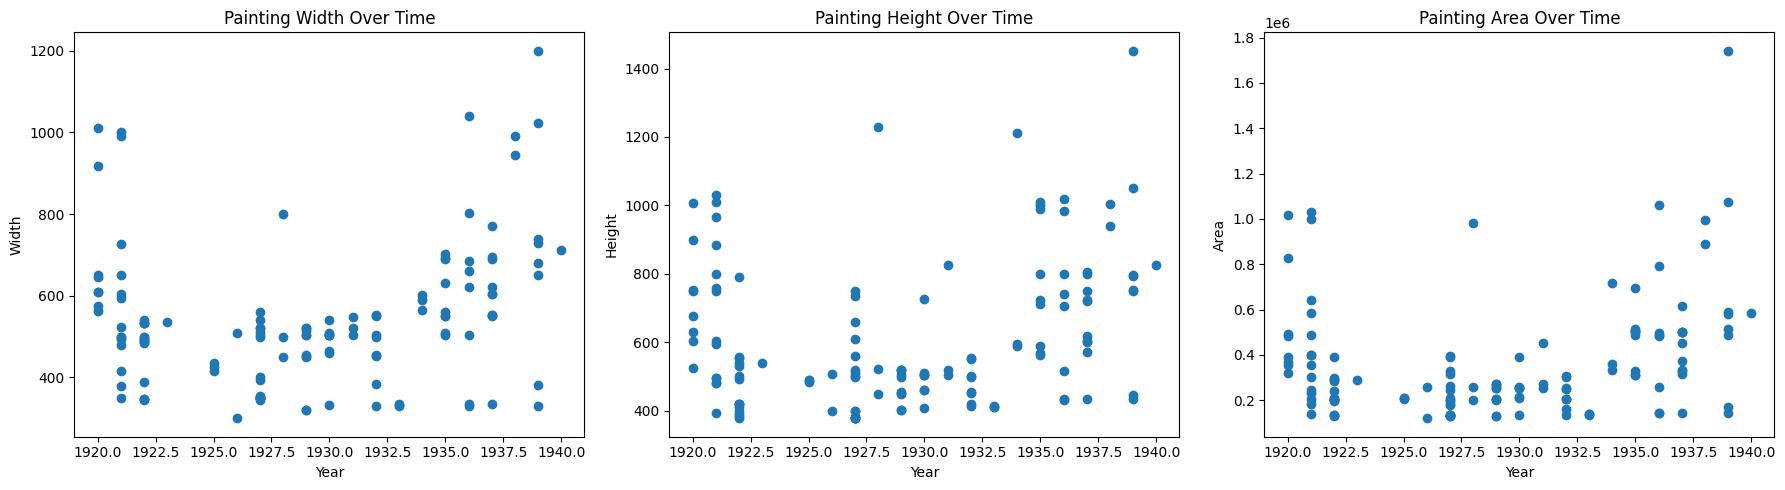

In [ ]:
import matplotlib.pyplot as plt

# Create a figure and a set of subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot year vs. width
axes[0].scatter(painting_info['year'], painting_info['width'])
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Width')
axes[0].set_title('Painting Width Over Time')

# Plot year vs. height
axes[1].scatter(painting_info['year'], painting_info['height'])
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Height')
axes[1].set_title('Painting Height Over Time')

# Plot year vs. area
axes[2].scatter(painting_info['year'], painting_info['area'])
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Area')
axes[2].set_title('Painting Area Over Time')

plt.tight_layout()
plt.show()

In [ ]:
blue_features = features[features['color'] == 'blue']
blue_features.head()

,painting_id,feature,x,y,width,height,color,rgb
5,b104,rect,263,18,464,111,blue,#233c55
9,b104,rect,949,134,61,143,blue,#233c55
12,b104,rect,536,282,191,343,blue,#233c55
23,b104,rect,732,771,212,172,blue,#233c55
49,b105,rect,582,143,218,69,blue,#36477a


In [ ]:
blue_features['feature_area_blue'] = blue_features['width'] * blue_features['height']
blue_features.head()

/tmp/ipykernel_441/716385014.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  blue_features['feature_area_blue'] = blue_features['width'] * blue_features['height']


,painting_id,feature,x,y,width,height,color,rgb,feature_area_blue
5,b104,rect,263,18,464,111,blue,#233c55,51504
9,b104,rect,949,134,61,143,blue,#233c55,8723
12,b104,rect,536,282,191,343,blue,#233c55,65513
23,b104,rect,732,771,212,172,blue,#233c55,36464
49,b105,rect,582,143,218,69,blue,#36477a,15042


In [ ]:
blue_features = features[features['color'] == 'blue'].copy()
blue_features['feature_area_blue'] = blue_features['width'] * blue_features['height']

blue_area_per_painting = blue_features.groupby('painting_id')['feature_area_blue'].sum().reset_index(name='blue_area')
painting_info = painting_info.merge(blue_area_per_painting, on='painting_id', how='left')
painting_info.head()

,painting_id,year,title,width,height,complexity,area,blue_area
0,b104,1920,No. VI,1010,1007,41,1017070,162204.0
1,b105,1920,Composition A,918,900,42,826200,98645.0
2,b106,1920,Composition B,575,677,41,389275,87395.0
3,b107,1920,Composition C,610,603,44,367830,98919.0
4,b108,1920,Composition I,646,750,44,484500,47813.0


In [ ]:
painting_info['blue_percentage'] = (painting_info['blue_area'] / painting_info['area'] * 100).fillna(0)
painting_info.head()

,painting_id,year,title,width,height,complexity,area,blue_area,blue_percentage
0,b104,1920,No. VI,1010,1007,41,1017070,162204.0,15.948165
1,b105,1920,Composition A,918,900,42,826200,98645.0,11.939603
2,b106,1920,Composition B,575,677,41,389275,87395.0,22.450710
3,b107,1920,Composition C,610,603,44,367830,98919.0,26.892586
4,b108,1920,Composition I,646,750,44,484500,47813.0,9.868524


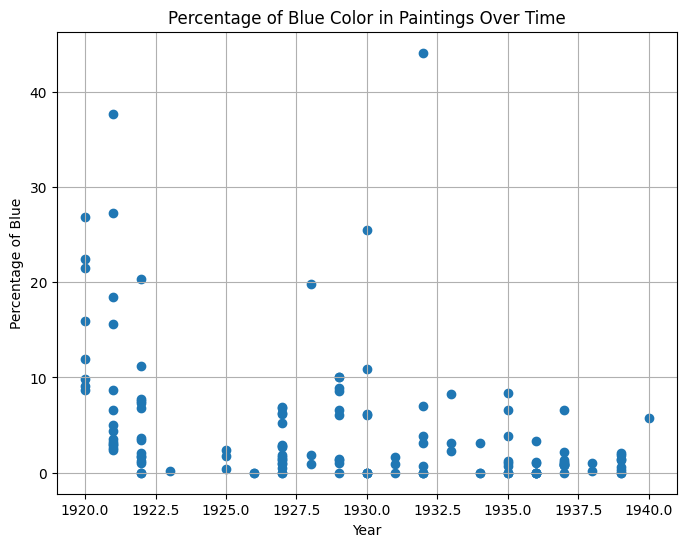

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(painting_info['year'], painting_info['blue_percentage'])
plt.xlabel('Year')
plt.ylabel('Percentage of Blue')
plt.title('Percentage of Blue Color in Paintings Over Time')
plt.grid(True)
plt.show()

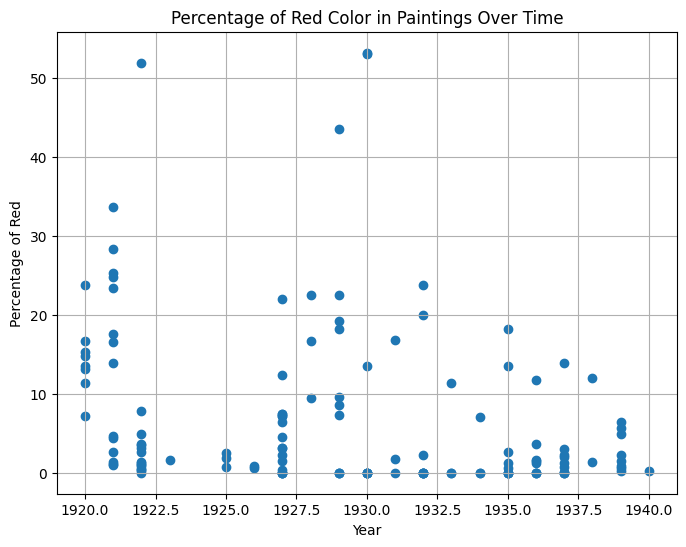

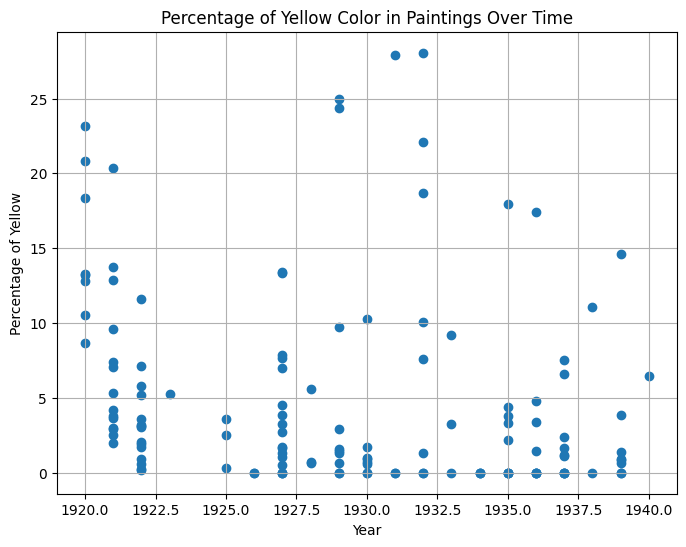

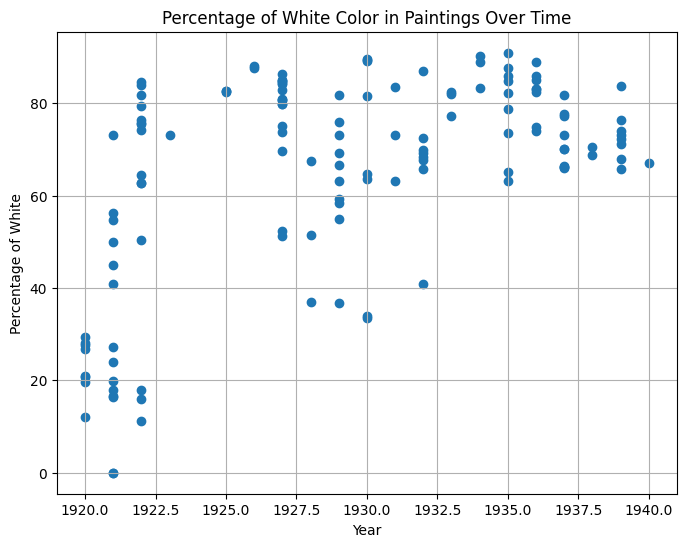

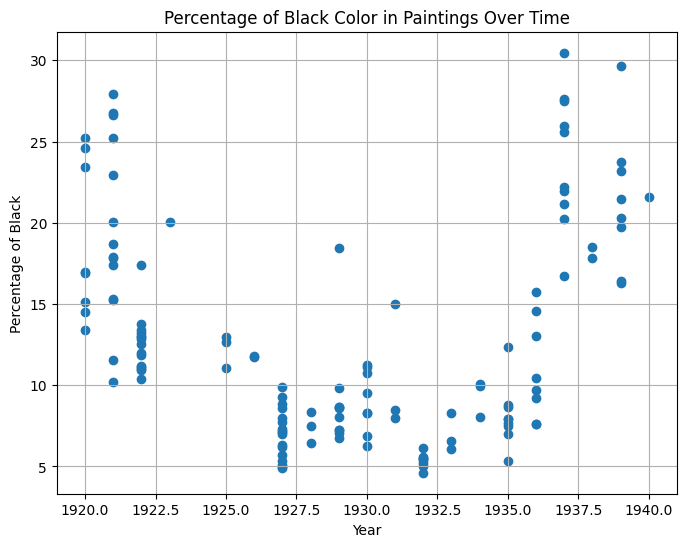

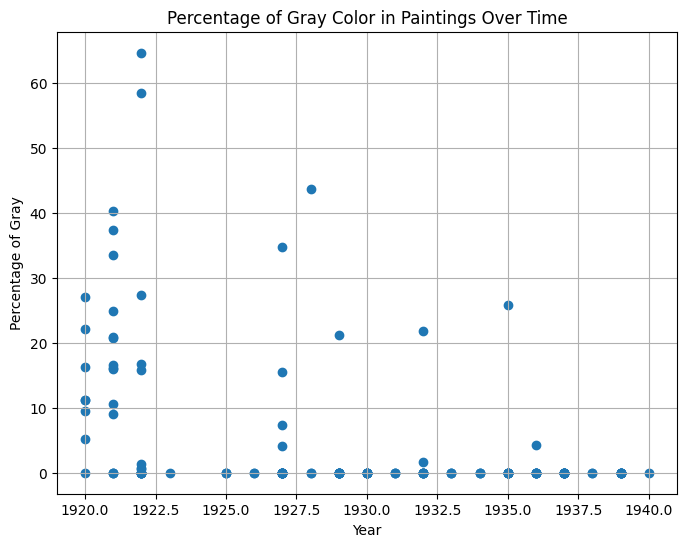

In [ ]:
colors_to_analyze = ['red', 'yellow', 'white', 'black', 'gray']

for current_color in colors_to_analyze:
    # a. Create a temporary DataFrame for the current color's features
    color_features = features[features['color'] == current_color].copy()

    # b. Calculate the area for each feature of the current color
    color_features[f'feature_area_{current_color}'] = color_features['width'] * color_features['height']

    # c. Group this temporary DataFrame by 'painting_id' and sum the feature_area_current_color
    color_area_per_painting = color_features.groupby('painting_id')[f'feature_area_{current_color}'].sum().reset_index(name=f'{current_color}_area')

    # d. Merge this new DataFrame with the painting_info DataFrame
    painting_info = painting_info.merge(color_area_per_painting, on='painting_id', how='left')

    # e. Calculate the percentage of the current color for each painting
    painting_info[f'{current_color}_percentage'] = (painting_info[f'{current_color}_area'] / painting_info['area'] * 100).fillna(0)

    # f. Create a scatter plot
    plt.figure(figsize=(8, 6))
    plt.scatter(painting_info['year'], painting_info[f'{current_color}_percentage'])
    plt.xlabel('Year')
    plt.ylabel(f'Percentage of {current_color.capitalize()}')
    plt.title(f'Percentage of {current_color.capitalize()} Color in Paintings Over Time')
    plt.grid(True)
    plt.show()

#Mineria de Datos


##**Primer Parcial**

### Introducción


####1.1.1 Conceptos

La minería de datos es el proceso de extraer información útil a partir de una acumulación de datos, a menudo provenientes de un almacén o de una recopilación de data sets vinculados. Las herramientas para minería de datos incluyen potentes capacidades estadísticas, matemáticas y analíticas cuyo propósito principal es examinar grandes data sets para identificar tendencias, patrones y relaciones a fin de dar soporte a la toma de decisiones y planificación fundamentadas.

#### 1.1.2 Ciencia de datos

La ciencia de datos es un campo interdisciplinario que combina matemáticas, estadística, programación, inteligencia artificial (IA) y aprendizaje automático (machine learning) para analizar grandes volúmenes de datos estructurados y no estructurados. Su objetivo principal es extraer información valiosa que permita tomar decisiones estratégicas y resolver problemas empresariales.

In [ ]:
In [1]: help(len)

Help on built-in function len in module builtins:

len(obj, /)
    Return the number of items in a container.



In [ ]:
L = [1, 2, 3]
L.insert?

In [ ]:
L?

Iphyton Magic Comands

In [ ]:
def donothing(x):
  return x

In [ ]:
#El comando timeit sirve para evaluar el desempeño en terminos de tiempo
%timeit L = [n ** 2 for n in range(1000)]

68.5 µs ± 1.15 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [ ]:
#El comando %%timeit sirve tambien para evaluar solo que este abarca varias lineas de codigo en lugar de solo 1
%%timeit
L=[]
for n in range(1000):
  L.append(n**2)

103 µs ± 28.9 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [ ]:
%timeit?

In [ ]:
%%timeit?

IPython and Shell Commands

In [ ]:
!ls

drive  sample_data


In [ ]:
%cd sample_data/

/content/sample_data


In [ ]:
%ls

anscombe.json*                mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md*


In [ ]:
!cat README.md

This directory includes a few sample datasets to get you started.

*   `california_housing_data*.csv` is California housing data from the 1990 US
    Census; more information is available at:
    https://docs.google.com/document/d/e/2PACX-1vRhYtsvc5eOR2FWNCwaBiKL6suIOrxJig8LcSBbmCbyYsayia_DvPOOBlXZ4CAlQ5nlDD8kTaIDRwrN/pub

*   `mnist_*.csv` is a small sample of the
    [MNIST database](https://en.wikipedia.org/wiki/MNIST_database), which is
    described at: http://yann.lecun.com/exdb/mnist/

*   `anscombe.json` contains a copy of
    [Anscombe's quartet](https://en.wikipedia.org/wiki/Anscombe%27s_quartet); it
    was originally described in

    Anscombe, F. J. (1973). 'Graphs in Statistical Analysis'. American
    Statistician. 27 (1): 17-21. JSTOR 2682899.

    and our copy was prepared by the
    [vega_datasets library](https://github.com/altair-viz/vega_datasets/blob/4f67bdaad10f45e3549984e17e1b3088c731503d/vega_datasets/_data/anscombe.json).


In [ ]:
contents = !ls
print(contents)

['anscombe.json\t\t      mnist_test.csv', 'california_housing_test.csv   mnist_train_small.csv', 'california_housing_train.csv  README.md']


In [ ]:
directory = !pwd

In [ ]:
print(directory)

['/content/sample_data']


In [ ]:
type(directory)

IPython.utils.text.SList

In [ ]:
%env

{'SHELL': '/bin/bash',
 'COLAB_JUPYTER_TRANSPORT': 'ipc',
 'CGROUP_MEMORY_EVENTS': '/sys/fs/cgroup/memory.events /var/colab/cgroup/jupyter-children/memory.events',
 'VM_GCE_METADATA_HOST': '169.254.169.253',
 'MODEL_PROXY_HOST': 'https://mp.kaggle.net',
 'HOSTNAME': '73628ad1e53a',
 'LANGUAGE': 'en_US',
 'TBE_RUNTIME_ADDR': '172.28.0.1:8011',
 'GCE_METADATA_TIMEOUT': '3',
 'COLAB_JUPYTER_IP': '172.28.0.12',
 'COLAB_LANGUAGE_SERVER_PROXY_ROOT_URL': 'http://172.28.0.1:8013/',
 'KMP_LISTEN_PORT': '6000',
 'TF_FORCE_GPU_ALLOW_GROWTH': 'true',
 'ENV': '/root/.bashrc',
 'PWD': '/',
 'TBE_EPHEM_CREDS_ADDR': '172.28.0.1:8009',
 'COLAB_LANGUAGE_SERVER_PROXY_REQUEST_TIMEOUT': '30s',
 'TBE_CREDS_ADDR': '172.28.0.1:8008',
 'COLAB_JUPYTER_TOKEN': '<hidden>',
 'LAST_FORCED_REBUILD': '20250623',
 'TCLLIBPATH': '/usr/share/tcltk/tcllib1.20',
 'COLAB_KERNEL_MANAGER_PROXY_HOST': '172.28.0.12',
 'UV_BUILD_CONSTRAINT': '',
 'COLAB_WARMUP_DEFAULTS': '1',
 'HOME': '/root',
 'LANG': 'en_US.UTF-8',
 'CLOUDSDK

Understanding Data Types in Python

In [ ]:
L3 = [True, "2", 3.0, 4]
[type(item) for item in L3]

[bool, str, float, int]

In [ ]:
import array
L=list(range(10))
A=array.array('i',L)
A

array('i', [0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
import numpy as np

In [ ]:
np.array([1,4,2,5,3])

array([1, 4, 2, 5, 3])

In [ ]:
np.array([3.14,4,2,3])

array([3.14, 4.  , 2.  , 3.  ])

In [ ]:
np.array([1,2,3,4],dtype='float32')

array([1., 2., 3., 4.], dtype=float32)

In [ ]:
np.array([1,2,3,4], dtype='int')

array([1, 2, 3, 4])

In [ ]:
np.array([range(i,i+3) for i in [2,4,6]])

array([[2, 3, 4],
       [4, 5, 6],
       [6, 7, 8]])

The Basics of NumPy Arrays

In [ ]:
import numpy as np
np.random.seed(0)

x1 = np.random.randint(10, size=6)  # One-dimensional array
x2 = np.random.randint(10, size=(3, 4))  # Two-dimensional array
x3 = np.random.randint(10, size=(3, 4, 5))  # Three-dimensional array

In [ ]:
print("x3 ndim: ", x3.ndim)
print("x3 shape:", x3.shape)
print("x3 size: ", x3.size)

x3 ndim:  3
x3 shape: (3, 4, 5)
x3 size:  60


In [ ]:
print("dtype:", x3.dtype)

dtype: int64


In [ ]:
print("itemsize:", x3.itemsize, "bytes")
print("nbytes:", x3.nbytes, "bytes")

itemsize: 8 bytes
nbytes: 480 bytes


Array Indexing: Accessing Single Elements

In [ ]:
x1

array([5, 0, 3, 3, 7, 9])

In [ ]:
x1[0]

np.int64(5)

In [ ]:
x1[4]

np.int64(7)

In [ ]:
x1[-1]

np.int64(9)

In [ ]:
x2

array([[3, 5, 2, 4],
       [7, 6, 8, 8],
       [1, 6, 7, 7]])

In [ ]:
x2[0, 0]

np.int64(3)

In [ ]:
x2[0, 0] = 12

In [ ]:
x2[2, 3] #Primero renglon y despues columna

np.int64(7)

In [ ]:
x1[0] = 3.14159
x1

array([3, 0, 3, 3, 7, 9])

Array Slicing: Accessing Subarrays

In [ ]:
x = np.arange(10)
x

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
x[:5]  # first five elements

array([0, 1, 2, 3, 4])

In [ ]:
x[5:]  # elements after index 5

array([5, 6, 7, 8, 9])

In [ ]:
x[4:7]  # middle subarray

array([4, 5, 6])

In [ ]:
x[::2]  # every other element

array([0, 2, 4, 6, 8])

In [ ]:
x[1::2]  # every other element, starting at index 1

array([1, 3, 5, 7, 9])

In [ ]:
x[::-1]  # all elements, reversed

array([9, 8, 7, 6, 5, 4, 3, 2, 1, 0])

In [ ]:
x[5::-2]  # reversed every other from index 5

array([5, 3, 1])

In [ ]:
x2

array([[12,  5,  2,  4],
       [ 7,  6,  8,  8],
       [ 1,  6,  7,  7]])

In [ ]:
x2[:2, :3]  # two rows, three columns

array([[12,  5,  2],
       [ 7,  6,  8]])

In [ ]:
x2[:3, ::2]  # all rows, every other column

array([[12,  2],
       [ 7,  8],
       [ 1,  7]])

In [ ]:
x2[::-1, ::-1]

array([[ 7,  7,  6,  1],
       [ 8,  8,  6,  7],
       [ 4,  2,  5, 12]])

In [ ]:
print(x2[:, 0])  # first column of x2

[12  7  1]


In [ ]:
print(x2[0, :])  # first row of x2

[12  5  2  4]


In [ ]:
print(x2[0])  # equivalent to x2[0, :]

[12  5  2  4]


In [ ]:
print(x2)

[[12  5  2  4]
 [ 7  6  8  8]
 [ 1  6  7  7]]


In [ ]:
x2_sub = x2[:2, :2]
print(x2_sub)

[[12  5]
 [ 7  6]]


In [ ]:
x2_sub[0, 0] = 99
print(x2_sub)

[[99  5]
 [ 7  6]]


In [ ]:
print(x2)

[[99  5  2  4]
 [ 7  6  8  8]
 [ 1  6  7  7]]


In [ ]:
x2_sub_copy = x2[:2, :2].copy()
print(x2_sub_copy)

[[99  5]
 [ 7  6]]


In [ ]:
x2_sub_copy[0, 0] = 42
print(x2_sub_copy)

[[42  5]
 [ 7  6]]


#### Estadistica Básica

In [ ]:
import numpy as np

In [ ]:
data = np.array([1, 2, 3, 4, 5])
media = np.mean(data)
print(media)

3.0


In [ ]:
data = np.array([1, 2, 3, 4, 5])
weights = np.array([1, 2, 3, 4, 5])
promedio = np.average(data)
promedio_ponderado = np.average(data, weights=weights)

In [ ]:
mediana = np.median(data)

In [ ]:
varianza = np.var(data)
desviacion = np.std(data)

In [ ]:
muestra = np.random.normal(0, 1, 1000)
print(np.mean(muestra), np.std(muestra))

-0.006543456960417206 1.0059985778093545


In [ ]:
corr = np.corrcoef([1,2,3], [1,5,7])

Cuadros Estadisticos

In [ ]:
import numpy as np
import pandas as pd
from io import StringIO

raw = """Marca temporal\tNúmero de matrícula\t¿Cuántos años cumplidos tienes?\t¿Has realizado programas utilizando Python?\t¿Has utilizado Google Colab?\t¿Tienes cuenta de GitHub?
19/01/2026 18:32:18\t178920\t22\tSi\tNo\tSi
19/01/2026 18:32:23\t182712\t21\tSi\tNo\tSi
19/01/2026 18:32:25\t180370\t26\tSi\tSi\tSi
19/01/2026 18:32:27\t182570\t21\tSi\tSi\tSi
19/01/2026 18:32:28\t177622\t24\tSi\tNo\tSi
19/01/2026 18:32:29\t175166\t22\tSi\tSi\tSi
19/01/2026 18:32:30\t177573\t22\tSi\tSi\tSi
19/01/2026 18:32:35\t178430\t21\tSi\tSi\tSi
19/01/2026 18:32:38\t179169\t23\tSi\tNo\tSi
19/01/2026 18:32:41\t177263\t22\tSi\tSi\tSi
19/01/2026 18:32:48\t179884\t23\tSi\tNo\tSi
19/01/2026 18:32:48\t183016\t22\tSi\tNo\tSi
19/01/2026 18:32:50\t179033\t23\tSi\tSi\tNo
19/01/2026 18:32:54\t178218\t22\tSi\tNo\tSi
19/01/2026 18:32:55\t178446\t22\tSi\tSi\tSi
19/01/2026 18:33:00\t178166\t22\tSi\tSi\tNo
19/01/2026 18:33:02\t177406\t22\tSi\tNo\tSi
19/01/2026 18:33:05\t177192\t22\tSi\tSi\tSi
19/01/2026 18:33:08\t182451\t21\tSi\tNo\tSi
19/01/2026 18:33:08\t171513\t24\tNo\tNo\tSi
19/01/2026 18:33:09\t181619\t21\tSi\tNo\tSi
19/01/2026 18:33:12\t182298\t23\tSi\tNo\tSi
19/01/2026 18:33:14\t181419\t24\tNo\tNo\tSi
19/01/2026 18:33:32\t177291\t21\tSi\tSi\tSi
19/01/2026 18:33:42\t182085\t22\tSi\tNo\tSi
19/01/2026 18:33:53\t176453\t22\tSi\tNo\tSi
19/01/2026 18:34:04\t176263\t24\tSi\tNo\tSi
19/01/2026 18:34:06\t179997\t21\tSi\tNo\tSi
19/01/2026 18:36:21\t175842\t23\tSi\tNo\tNo
19/01/2026 20:19:21\t179913\t20\tSi\tNo\tSi
19/01/2026 20:19:48\t177301\t22\tSi\tSi\tNo
19/01/2026 20:20:06\t183060\t21\tSi\tNo\tSi
19/01/2026 20:20:08\t177935\t22\tSi\tSi\tSi
19/01/2026 20:20:19\t177700\t20\tSi\tSi\tSi
19/01/2026 20:20:26\t178318\t24\tSi\tSi\tSi
19/01/2026 20:20:27\t174653\t24\tSi\tNo\tSi
19/01/2026 20:20:29\t177139\t21\tSi\tNo\tSi
19/01/2026 20:20:31\t173479\t25\tSi\tNo\tNo
19/01/2026 20:20:39\t175588\t23\tNo\tNo\tSi
19/01/2026 20:20:45\t178774\t23\tSi\tSi\tSi
19/01/2026 20:20:45\t175031\t23\tSi\tNo\tNo
19/01/2026 20:20:49\t178396\t21\tSi\tSi\tSi
19/01/2026 20:20:49\t172068\t23\tNo\tNo\tNo
19/01/2026 20:20:50\t174197\t23\tNo\tNo\tSi
19/01/2026 20:20:55\t178584\t22\tSi\tNo\tSi
19/01/2026 20:20:55\t175329\t24\tSi\tNo\tSi
19/01/2026 20:20:56\t177685\t22\tSi\tSi\tSi
19/01/2026 20:20:57\t178678\t22\tNo\tNo\tSi
19/01/2026 20:21:04\t177143\t22\tSi\tNo\tSi
19/01/2026 20:21:07\t182318\t26\tSi\tNo\tSi
19/01/2026 20:21:27\t182377\t20\tSi\tNo\tSi
19/01/2026 20:21:34\t179419\t22\tSi\tNo\tNo
19/01/2026 20:21:35\t181662\t21\tSi\tNo\tSi
19/01/2026 20:21:38\t181760\t21\tSi\tNo\tSi
19/01/2026 20:22:06\t177888\t22\tSi\tNo\tSi
19/01/2026 20:22:15\t176535\t25\tSi\tNo\tSi
19/01/2026 20:22:29\t179862\t21\tSi\tNo\tSi
19/01/2026 20:22:32\t178378\t22\tSi\tNo\tSi
19/01/2026 20:22:50\t177451\t22\tSi\tNo\tSi
19/01/2026 20:23:15\t179804\t21\tSi\tNo\tSi
"""

# Cargar datos
df = pd.read_csv(StringIO(raw), sep='\t')
df.columns = [c.strip() for c in df.columns]

# Variables
df['edad'] = pd.to_numeric(df['¿Cuántos años cumplidos tienes?'], errors='coerce')
map_sn = {'Si': True, 'No': False}
df['prog_python'] = df['¿Has realizado programas utilizando Python?'].map(map_sn)
df['usa_colab'] = df['¿Has utilizado Google Colab?'].map(map_sn)
df['cuenta_github'] = df['¿Tienes cuenta de GitHub?'].map(map_sn)


In [ ]:
df.head()

,Marca temporal,Número de matrícula,¿Cuántos años cumplidos tienes?,¿Has realizado programas utilizando Python?,¿Has utilizado Google Colab?,¿Tienes cuenta de GitHub?,edad,prog_python,usa_colab,cuenta_github
0,19/01/2026 18:32:18,178920,22,Si,No,Si,22,True,False,True
1,19/01/2026 18:32:23,182712,21,Si,No,Si,21,True,False,True
2,19/01/2026 18:32:25,180370,26,Si,Si,Si,26,True,True,True
3,19/01/2026 18:32:27,182570,21,Si,Si,Si,21,True,True,True
4,19/01/2026 18:32:28,177622,24,Si,No,Si,24,True,False,True


In [ ]:
# A NumPy
edad = df['edad'].to_numpy(dtype=float)
prog_py = df['prog_python'].to_numpy(dtype=bool)
usa_colab = df['usa_colab'].to_numpy(dtype=bool)
cuenta_gh = df['cuenta_github'].to_numpy(dtype=bool)


In [ ]:
edad

array([22., 21., 26., 21., 24., 22., 22., 21., 23., 22., 23., 22., 23.,
       22., 22., 22., 22., 22., 21., 24., 21., 23., 24., 21., 22., 22.,
       24., 21., 23., 20., 22., 21., 22., 20., 24., 24., 21., 25., 23.,
       23., 23., 21., 23., 23., 22., 24., 22., 22., 22., 26., 20., 22.,
       21., 21., 22., 25., 21., 22., 22., 21.])

In [ ]:
prog_py

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True, False, False,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True])

In [ ]:
# Descriptivos de edad (NumPy)
summary_age = {
    'n': int(edad.size),
    'min': float(np.min(edad)),
    'p25': float(np.percentile(edad, 25)),
    'mediana': float(np.median(edad)),
    'media': float(np.mean(edad)),
    'p75': float(np.percentile(edad, 75)),
    'max': float(np.max(edad)),
    'rango(ptp)': float(np.ptp(edad)),
    'var_muestral': float(np.var(edad, ddof=1)),
    'std_muestral': float(np.std(edad, ddof=1)),
    'cv': float(np.std(edad, ddof=1)/np.mean(edad)),
}


In [ ]:
summary_age

{'n': 60,
 'min': 20.0,
 'p25': 21.0,
 'mediana': 22.0,
 'media': 22.3,
 'p75': 23.0,
 'max': 26.0,
 'rango(ptp)': 6.0,
 'var_muestral': 1.8406779661016948,
 'std_muestral': 1.3567158752302173,
 'cv': 0.06083927691615324}

In [ ]:
# Frecuencias (NumPy)
freq_python = {'Si': int(np.count_nonzero(prog_py)), 'No': int(edad.size - np.count_nonzero(prog_py))}
freq_colab  = {'Si': int(np.count_nonzero(usa_colab)), 'No': int(edad.size - np.count_nonzero(usa_colab))}
freq_gh     = {'Si': int(np.count_nonzero(cuenta_gh)), 'No': int(edad.size - np.count_nonzero(cuenta_gh))}


In [ ]:
print(freq_python)
print(freq_colab)
print(freq_gh)

{'Si': 54, 'No': 6}
{'Si': 18, 'No': 42}
{'Si': 52, 'No': 8}


In [ ]:
print(f'Freq. de utilizacion de Python: {freq_python}')
print(f'Freq. de utilizacion de Google Colab: {freq_colab}')

Freq. de utilizacion de Python: {'Si': 54, 'No': 6}
Freq. de utilizacion de Google Colab: {'Si': 18, 'No': 42}


In [ ]:
# Tablas cruzadas (NumPy)
def tabla2x2(a, b):
    t = np.zeros((2,2), dtype=int)
    t[1,1] = np.count_nonzero(a & b)
    t[1,0] = np.count_nonzero(a & ~b)
    t[0,1] = np.count_nonzero(~a & b)
    t[0,0] = np.count_nonzero(~a & ~b)
    return t


In [ ]:
tab_py_colab = tabla2x2(prog_py, usa_colab)
tab_py_gh    = tabla2x2(prog_py, cuenta_gh)
tab_colab_gh = tabla2x2(usa_colab, cuenta_gh)


In [ ]:
print(f'Tabla de contingencia entre Python y Google Colab:\n{tab_py_colab}')

Tabla de contingencia entre Python y Google Colab:
[[ 6  0]
 [36 18]]


In [ ]:
# Medias de edad por grupo (NumPy)
means_by_group = {
    'edad_promedio_Python': {'Si': float(np.mean(edad[prog_py])) if np.any(prog_py) else np.nan,
                             'No': float(np.mean(edad[~prog_py])) if np.any(~prog_py) else np.nan},
    'edad_promedio_Colab':  {'Si': float(np.mean(edad[usa_colab])) if np.any(usa_colab) else np.nan,
                             'No': float(np.mean(edad[~usa_colab])) if np.any(~usa_colab) else np.nan},
    'edad_promedio_GitHub': {'Si': float(np.mean(edad[cuenta_gh])) if np.any(cuenta_gh) else np.nan,
                             'No': float(np.mean(edad[~cuenta_gh])) if np.any(~cuenta_gh) else np.nan},
}

In [ ]:
summary_age, freq_python, freq_colab, freq_gh, tab_py_colab, tab_py_gh, tab_colab_gh, means_by_group

({'n': 60,
  'min': 20.0,
  'p25': 21.0,
  'mediana': 22.0,
  'media': 22.3,
  'p75': 23.0,
  'max': 26.0,
  'rango(ptp)': 6.0,
  'var_muestral': 1.8406779661016948,
  'std_muestral': 1.3567158752302173,
  'cv': 0.06083927691615324},
 {'Si': 54, 'No': 6},
 {'Si': 18, 'No': 42},
 {'Si': 52, 'No': 8},
 array([[ 6,  0],
        [36, 18]]),
 array([[ 1,  5],
        [ 7, 47]]),
 array([[ 5, 37],
        [ 3, 15]]),
 {'edad_promedio_Python': {'Si': 22.203703703703702, 'No': 23.166666666666668},
  'edad_promedio_Colab': {'Si': 22.11111111111111, 'No': 22.38095238095238},
  'edad_promedio_GitHub': {'Si': 22.21153846153846, 'No': 22.875}})

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Tamaño y estilo de gráficos
plt.rcParams["figure.dpi"] = 160
plt.style.use('seaborn-v0_8-whitegrid')

# Cargar datos
df = pd.read_csv('/content/drive/MyDrive/raw.csv')
df.columns = [c.strip() for c in df.columns]

# Variables
df['edad'] = pd.to_numeric(df['¿Cuántos años cumplidos tienes?'], errors='coerce')
map_sn = {'Si': True, 'No': False}
df['prog_python'] = df['¿Has realizado programas utilizando Python?'].map(map_sn)
df['usa_colab'] = df['¿Has utilizado Google Colab?'].map(map_sn)
df['cuenta_github'] = df['¿Tienes cuenta de GitHub?'].map(map_sn)

# --- Paleta de colores ---
accent  = '#2563eb'  # azul
accent2 = '#16a34a'  # verde
accent3 = '#f59e0b'  # ámbar
neutral = '#6b7280'  # gris

nos ayuda a ver hacia donde se concentran los datos ->

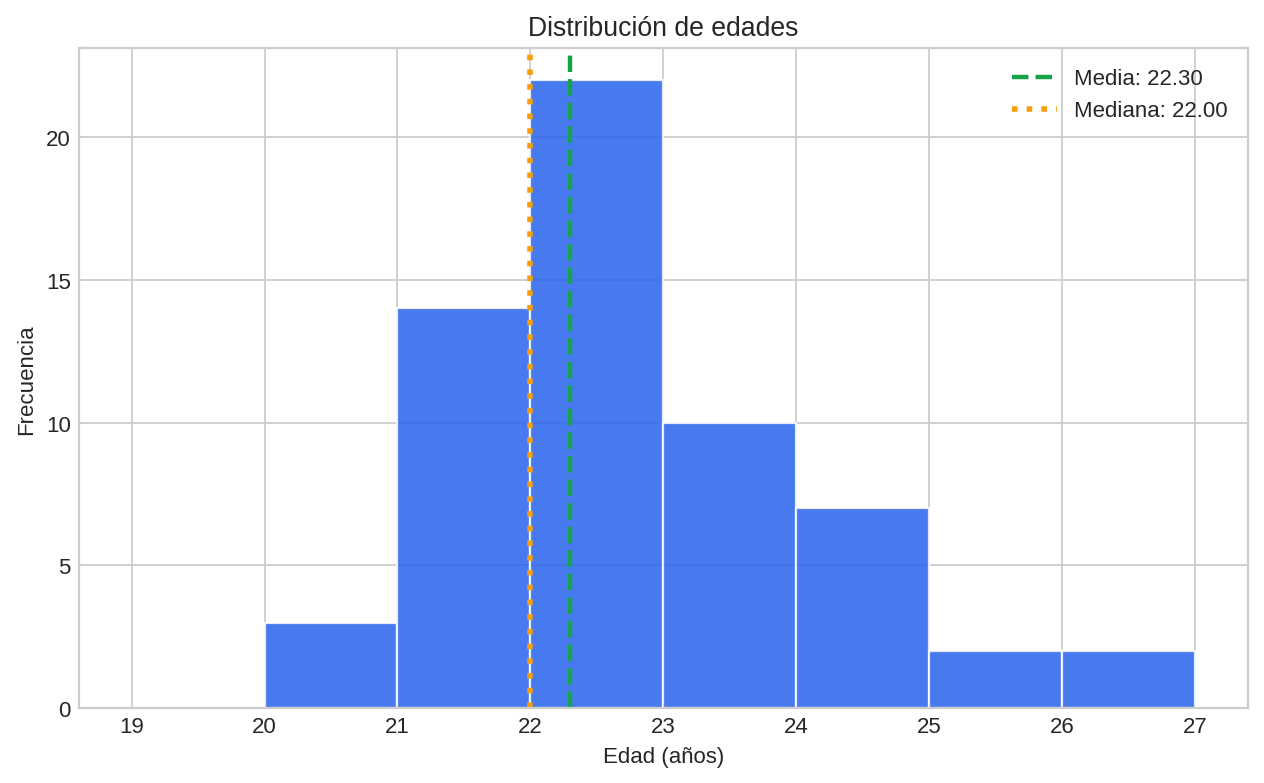

In [ ]:
# =========================
# 1) Histograma de edades
# =========================
fig, ax = plt.subplots(figsize=(8,5))
bins = range(int(df['edad'].min())-1, int(df['edad'].max())+2)
ax.hist(df['edad'], bins=bins, color=accent, edgecolor='white', alpha=0.85)
mean_age = df['edad'].mean()
med_age = df['edad'].median()
ax.axvline(mean_age, color=accent2, linestyle='--', linewidth=2, label=f"Media: {mean_age:.2f}")
ax.axvline(med_age, color=accent3, linestyle=':', linewidth=2.5, label=f"Mediana: {med_age:.2f}")
ax.set_title('Distribución de edades')
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()
fig.savefig('01_hist_edades.png', dpi=180)

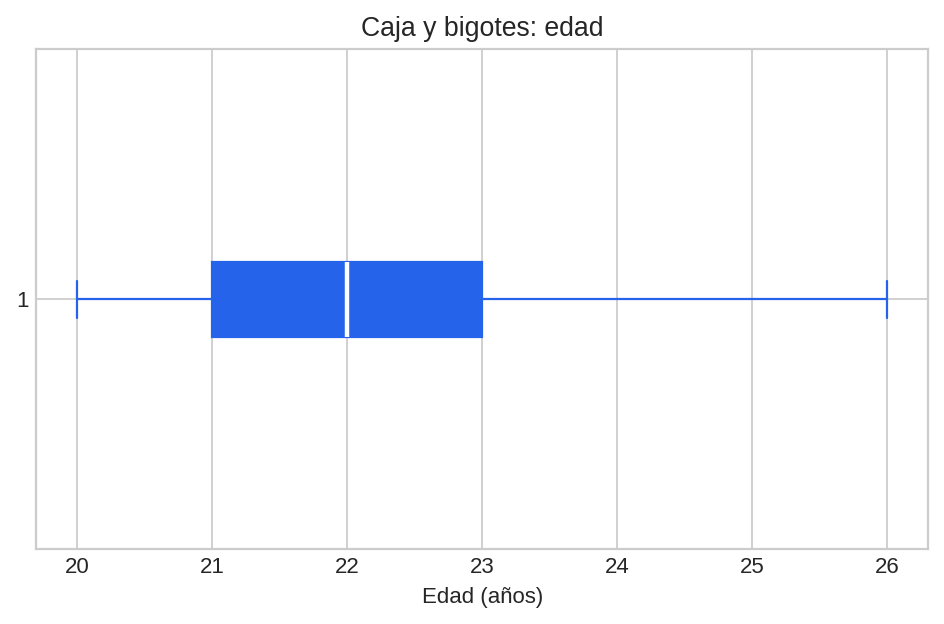

In [ ]:
# =======================
# 2) Boxplot de edades
# =======================
fig, ax = plt.subplots(figsize=(6,4))
ax.boxplot(df['edad'], vert=False, patch_artist=True,
           boxprops=dict(facecolor=accent, color=accent),
           medianprops=dict(color='white', linewidth=2),
           whiskerprops=dict(color=accent), capprops=dict(color=accent))
ax.set_title('Caja y bigotes: edad')
ax.set_xlabel('Edad (años)')
plt.tight_layout()
plt.show()
fig.savefig('02_box_edades.png', dpi=180)

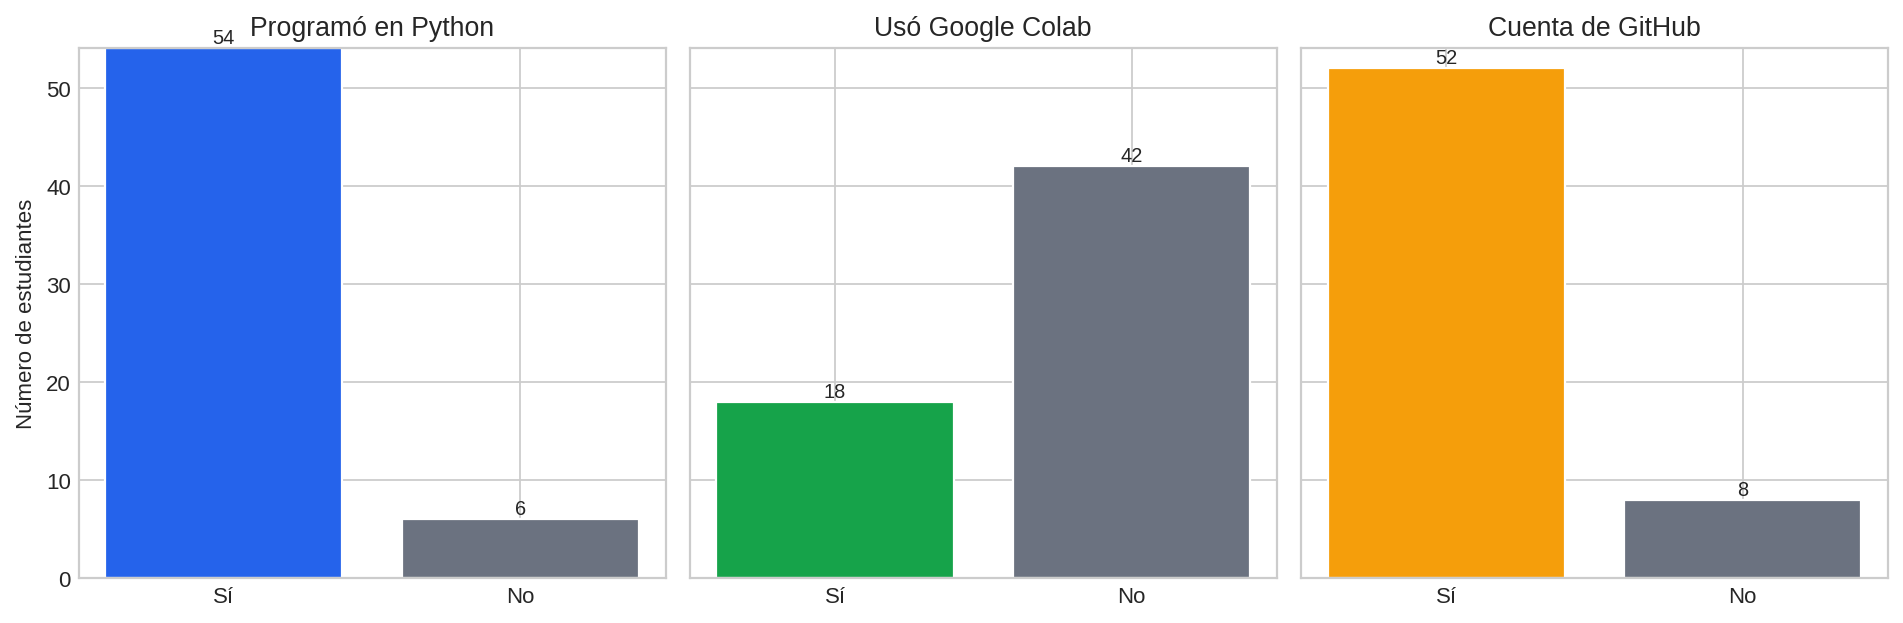

In [ ]:
# ====================================================
# 3) Barras: frecuencias de Sí/No para Python/Colab/GitHub
# ====================================================
fig, axes = plt.subplots(1,3, figsize=(12,4), sharey=True)
for ax, col, title, color in zip(
    axes,
    ['prog_python','usa_colab','cuenta_github'],
    ['Programó en Python','Usó Google Colab','Cuenta de GitHub'],
    [accent, accent2, accent3]
):
    counts = df[col].value_counts().reindex([True, False]).fillna(0).astype(int)
    labels = ['Sí','No']
    ax.bar(labels, counts, color=[color, neutral], edgecolor='white')
    ax.set_title(title)
    ax.set_ylim(0, max(counts.max(), 1)+2)
    for i, v in enumerate(counts):
        ax.text(i, v+0.1, str(v), ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('Número de estudiantes')
plt.tight_layout()
plt.show()
fig.savefig('03_barras_frecuencias.png', dpi=180)

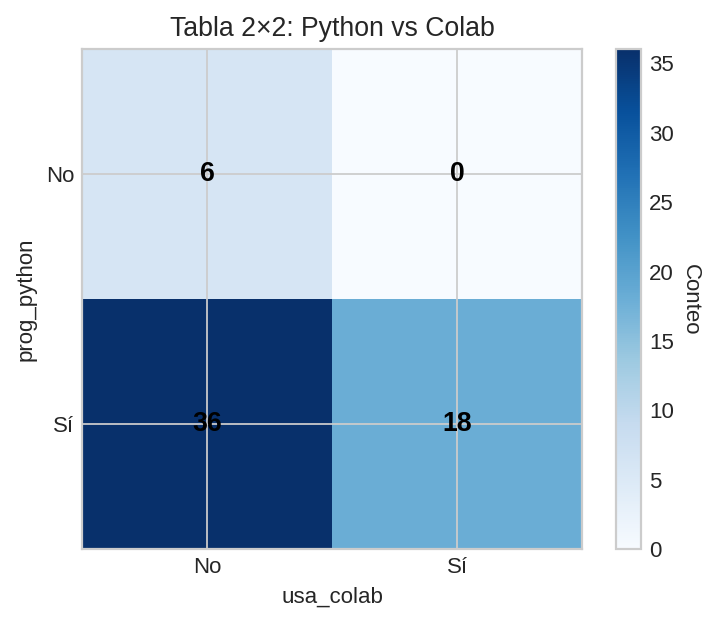

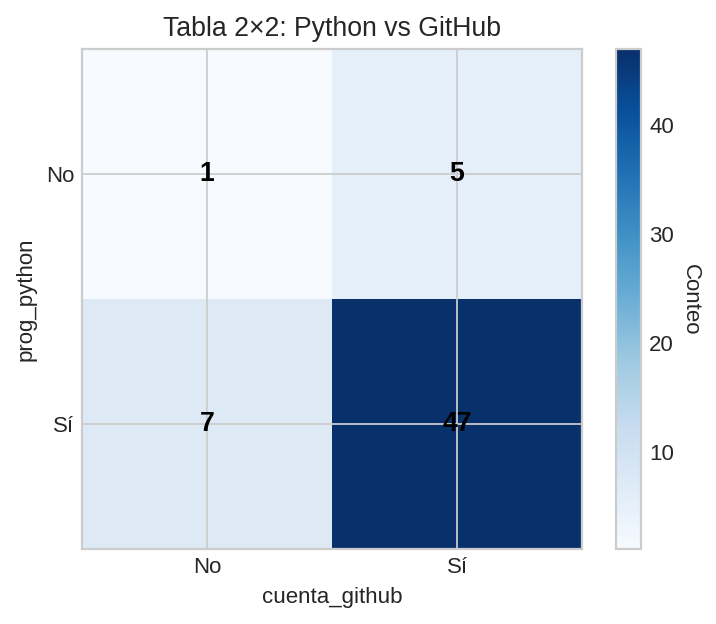

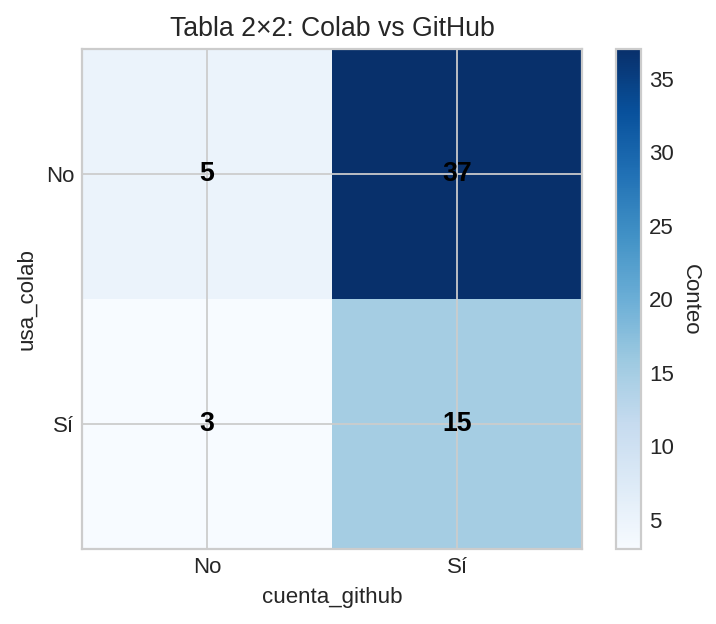

In [ ]:
# =======================================
# 4) Mapas de calor 2x2 para combinaciones
# =======================================
pairs = [
    ('prog_python','usa_colab','Python vs Colab'),
    ('prog_python','cuenta_github','Python vs GitHub'),
    ('usa_colab','cuenta_github','Colab vs GitHub')
]

for idx, (a,b,titulo) in enumerate(pairs, start=1):
    a_bool = df[a].to_numpy(dtype=bool)
    b_bool = df[b].to_numpy(dtype=bool)
    t = np.zeros((2,2), dtype=int)
    t[1,1] = np.count_nonzero(a_bool & b_bool)
    t[1,0] = np.count_nonzero(a_bool & ~b_bool)
    t[0,1] = np.count_nonzero(~a_bool & b_bool)
    t[0,0] = np.count_nonzero(~a_bool & ~b_bool)

    fig, ax = plt.subplots(figsize=(5,4))
    im = ax.imshow(t, cmap='Blues')
    ax.set_title(f'Tabla 2×2: {titulo}')
    ax.set_xticks([0,1]); ax.set_xticklabels(['No','Sí'])
    ax.set_yticks([0,1]); ax.set_yticklabels(['No','Sí'])
    ax.set_xlabel(b); ax.set_ylabel(a)

    for i in range(2):
        for j in range(2):
            ax.text(j, i, t[i,j], ha='center', va='center',
                    color='black', fontsize=12, fontweight='bold')

    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.set_ylabel('Conteo', rotation=270, labelpad=12)
    plt.tight_layout()
    plt.show()
    fig.savefig(f'04_heatmap_{idx}.png', dpi=180)

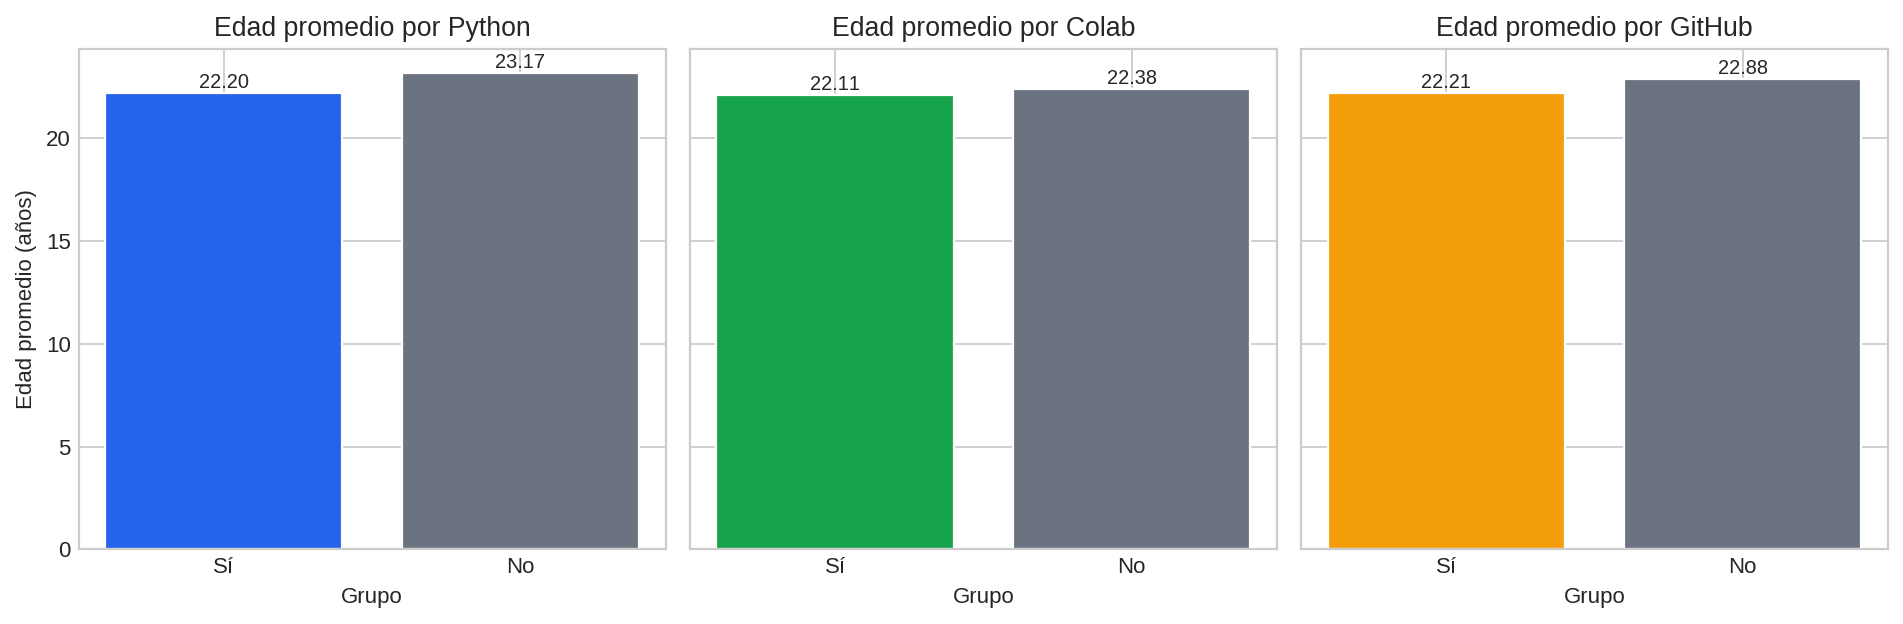

In [ ]:
# ======================================================
# 5) Barras: edad promedio por grupo (Sí/No) por variable
# ======================================================
fig, axes = plt.subplots(1,3, figsize=(12,4), sharey=True)
for ax, col, title, color in zip(
    axes,
    ['prog_python','usa_colab','cuenta_github'],
    ['Edad promedio por Python','Edad promedio por Colab','Edad promedio por GitHub'],
    [accent, accent2, accent3]
):
    means = df.groupby(col)['edad'].mean().reindex([True, False])
    labels = ['Sí','No']
    bars = ax.bar(labels, means, color=[color, neutral], edgecolor='white')
    for i, v in enumerate(means):
        ax.text(i, v+0.05, f"{v:.2f}", ha='center', va='bottom', fontsize=9)
    ax.set_title(title)
    ax.set_xlabel('Grupo')
axes[0].set_ylabel('Edad promedio (años)')
plt.tight_layout()
plt.show()
fig.savefig('05_barras_edad_promedio.png', dpi=180)

In [ ]:
# ===================================
# 6) Estadísticos de edad (impresión)
# ===================================
summary_age = {
    'n': int(df['edad'].size),
    'min': float(df['edad'].min()),
    'p25': float(np.percentile(df['edad'], 25)),
    'mediana': float(df['edad'].median()),
    'media': float(df['edad'].mean()),
    'p75': float(np.percentile(df['edad'], 75)),
    'max': float(df['edad'].max()),
    'rango(ptp)': float(np.ptp(df['edad'])),
    'var_muestral': float(np.var(df['edad'], ddof=1)),
    'std_muestral': float(np.std(df['edad'], ddof=1)),
    'cv': float(np.std(df['edad'], ddof=1)/np.mean(df['edad'])),
}
summary_age

{'n': 60,
 'min': 20.0,
 'p25': 21.0,
 'mediana': 22.0,
 'media': 22.3,
 'p75': 23.0,
 'max': 26.0,
 'rango(ptp)': 6.0,
 'var_muestral': 1.8406779661016952,
 'std_muestral': 1.3567158752302175,
 'cv': 0.06083927691615325}

MSE

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
anios_escolaridad = np.array([0, 3, 6, 9, 12, 16, 18])
ingreso_mensual_estimado_mx = np.array([12621, 15723, 19587, 24401, 30398, 40747, 47176])

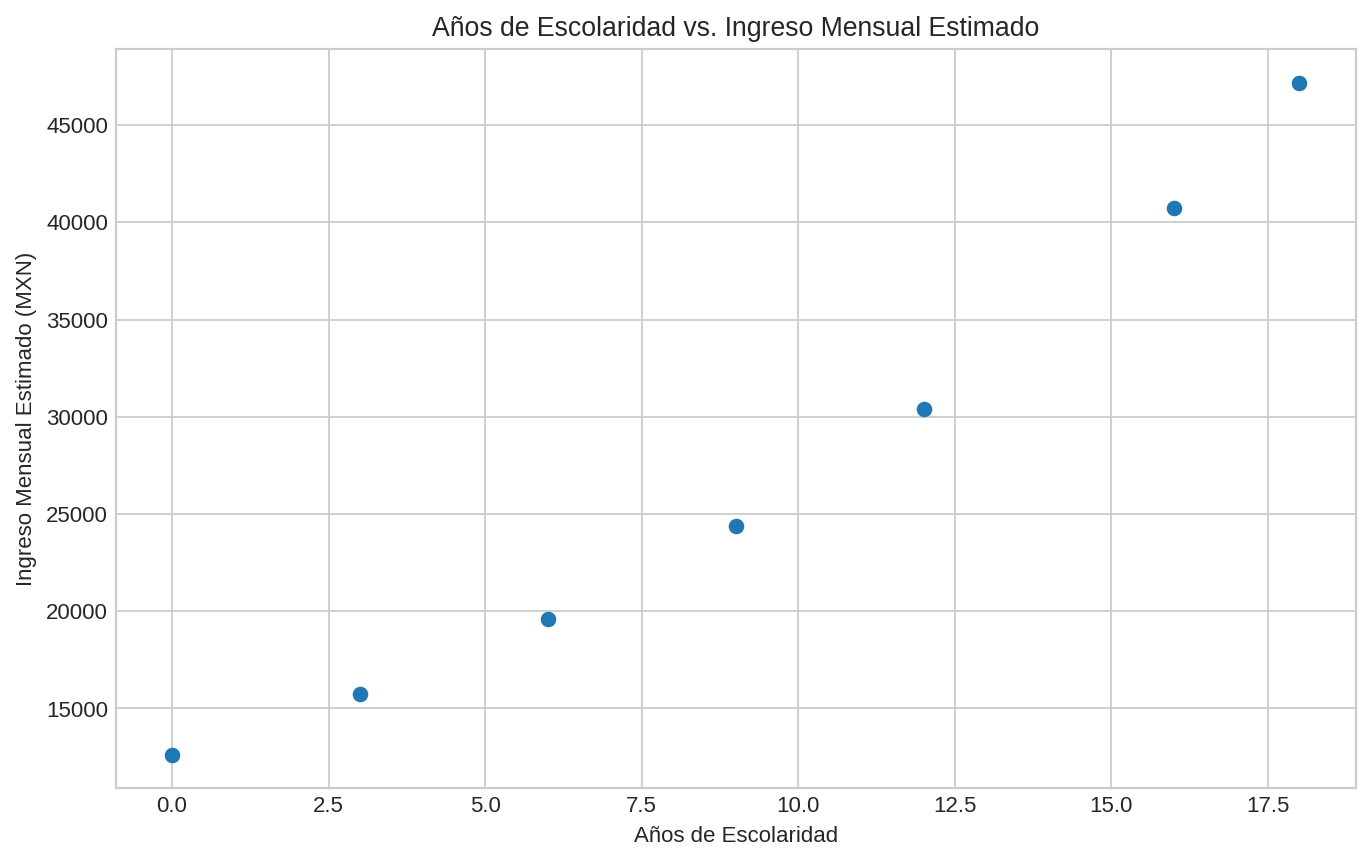

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(anios_escolaridad, ingreso_mensual_estimado_mx)
plt.title('Años de Escolaridad vs. Ingreso Mensual Estimado')
plt.xlabel('Años de Escolaridad')
plt.ylabel('Ingreso Mensual Estimado (MXN)')
plt.grid(True)
plt.show()

Primer intento de modelar los años de escolaridad y el ingreso estimado.   
Utilizar el primer punto y el útlimo para trazar una recta:
$$ m = \frac{y_{2}-y_{1}}{x_{2}-x_{1}}$$
$$ b= y_{1}-m*x_1$$

In [ ]:
x1 = anios_escolaridad[0]
y1 = ingreso_mensual_estimado_mx[0]
x2 = anios_escolaridad[-1]
y2 = ingreso_mensual_estimado_mx[-1]

m = (y2 - y1) / (x2 - x1)
b = y1 - m * x1

print(f"La ecuación de la recta es: y = {m:.2f}x + {b:.2f}")

La ecuación de la recta es: y = 1919.72x + 12621.00


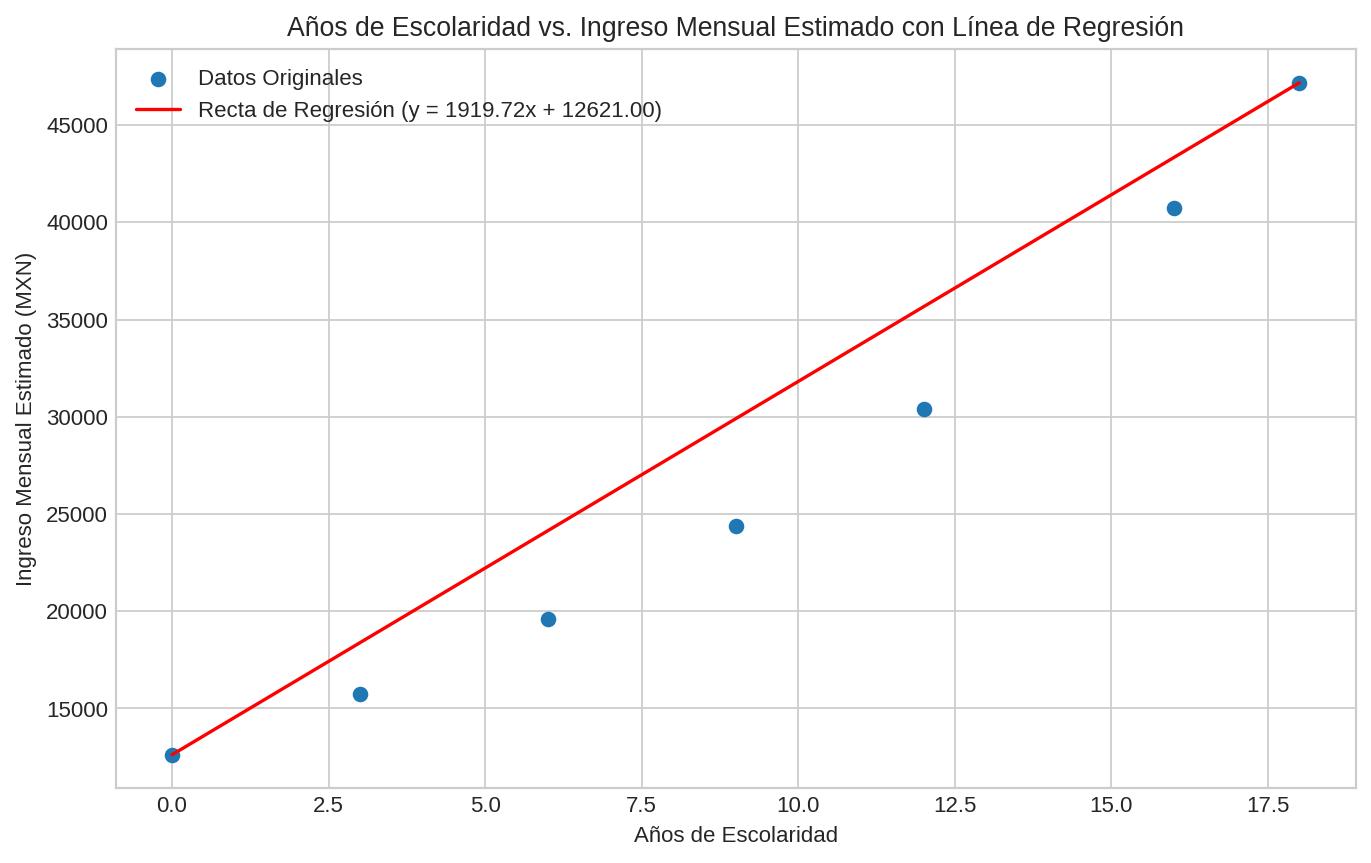

In [ ]:
import matplotlib.pyplot as plt

# Calcular los valores y de la recta utilizando m y b
linea_ingreso_estimado_new_plot = m * anios_escolaridad + b

plt.figure(figsize=(10, 6))
plt.scatter(anios_escolaridad, ingreso_mensual_estimado_mx, label='Datos Originales')
plt.plot(anios_escolaridad, linea_ingreso_estimado_new_plot, color='red',
         label=f'Recta de Regresión (y = {m:.2f}x + {b:.2f})')
plt.title('Años de Escolaridad vs. Ingreso Mensual Estimado con Línea de Regresión')
plt.xlabel('Años de Escolaridad')
plt.ylabel('Ingreso Mensual Estimado (MXN)')
plt.grid(True)
plt.legend()
plt.show()

Error Cuadrático Medio (MSE): Es la suma de los errores cuadrados dividida por el número total de puntos de datos. El MSE es una medida promedio de la magnitud de los errores. Un MSE más bajo indica que el modelo se ajusta mejor a los datos.

En este caso, el Error Cuadrático Medio (MSE) es de aproximadamente 13,196,667.31. Este número nos da una idea del rendimiento general de la recta que trazamos, mostrando la magnitud promedio de los errores al cuadrado entre los valores observados y los valores predichos por la línea.

Fórmula del MSE (Error Cuadrático Medio) del Inglés Mean Squared Error

$$MSE=\frac{Σ_{i=1}^{n}(Y_{i}- \hat{Y{i}})^2}{n}$$

$MSE$= Error cuadratico medio  
$n$= Número de datos   
$Y_{i}$=Valores Observados   
$\hat{Y_{i}}$=Valores predichos

In [ ]:
# 1. Calcular los valores predichos (y_pred) usando la ecuación de la recta
y_pred = m * anios_escolaridad + b
y_pred

array([12621.        , 18380.16666667, 24139.33333333, 29898.5       ,
       35657.66666667, 43336.55555556, 47176.        ])

In [ ]:
# 2. Calcular los errores (residuales): la diferencia entre los valores reales y los predichos
errores = ingreso_mensual_estimado_mx - y_pred
errores


array([    0.        , -2657.16666667, -4552.33333333, -5497.5       ,
       -5259.66666667, -2589.55555556,     0.        ])

In [ ]:
# 3. Elevar al cuadrado cada error
errores_cuadrados = errores**2
errores_cuadrados

array([       0.        ,  7060534.69444443, 20723738.77777776,
       30222506.25      , 27664093.44444442,  6705797.97530864,
              0.        ])

In [ ]:
# 4. Sumar los errores cuadrados
suma_errores_cuadrados = np.sum(errores_cuadrados)
suma_errores_cuadrados

np.float64(92376671.14197525)

In [ ]:
# 5. Dividir la suma de los errores cuadrados por el número de puntos para obtener el MSE
mse = suma_errores_cuadrados / len(anios_escolaridad)
mse

np.float64(13196667.305996465)

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np


In [ ]:
# Cambia la forma de anios_escolaridad a 2D array como es requerido por sklearn
X = anios_escolaridad.reshape(-1, 1)
y = ingreso_mensual_estimado_mx

X

array([[ 0],
       [ 3],
       [ 6],
       [ 9],
       [12],
       [16],
       [18]])

In [ ]:
# Crear y ajustar el modelo de regresión lineal
modelo_regresion = LinearRegression()
modelo_regresion.fit(X, y)

# Obtener los coeficientes (m) e intercepto (b) del nuevo modelo
m_sklearn = modelo_regresion.coef_[0]
b_sklearn = modelo_regresion.intercept_

print(f"Coefficients (m) from scikit-learn: {m_sklearn:.2f}")
print(f"Intercept (b) from scikit-learn: {b_sklearn:.2f}")

Coefficients (m) from scikit-learn: 1914.55
Intercept (b) from scikit-learn: 9731.66


Como ejercicios:

Grafica la línea del modelo de regresión lineal de sklearn junto con los datos originales.   
Calcula el MSE de esta regresión lineal y compara con el resultado anterior.   
¿Cuál recta tiene menos error con respecto a los datos originales?.


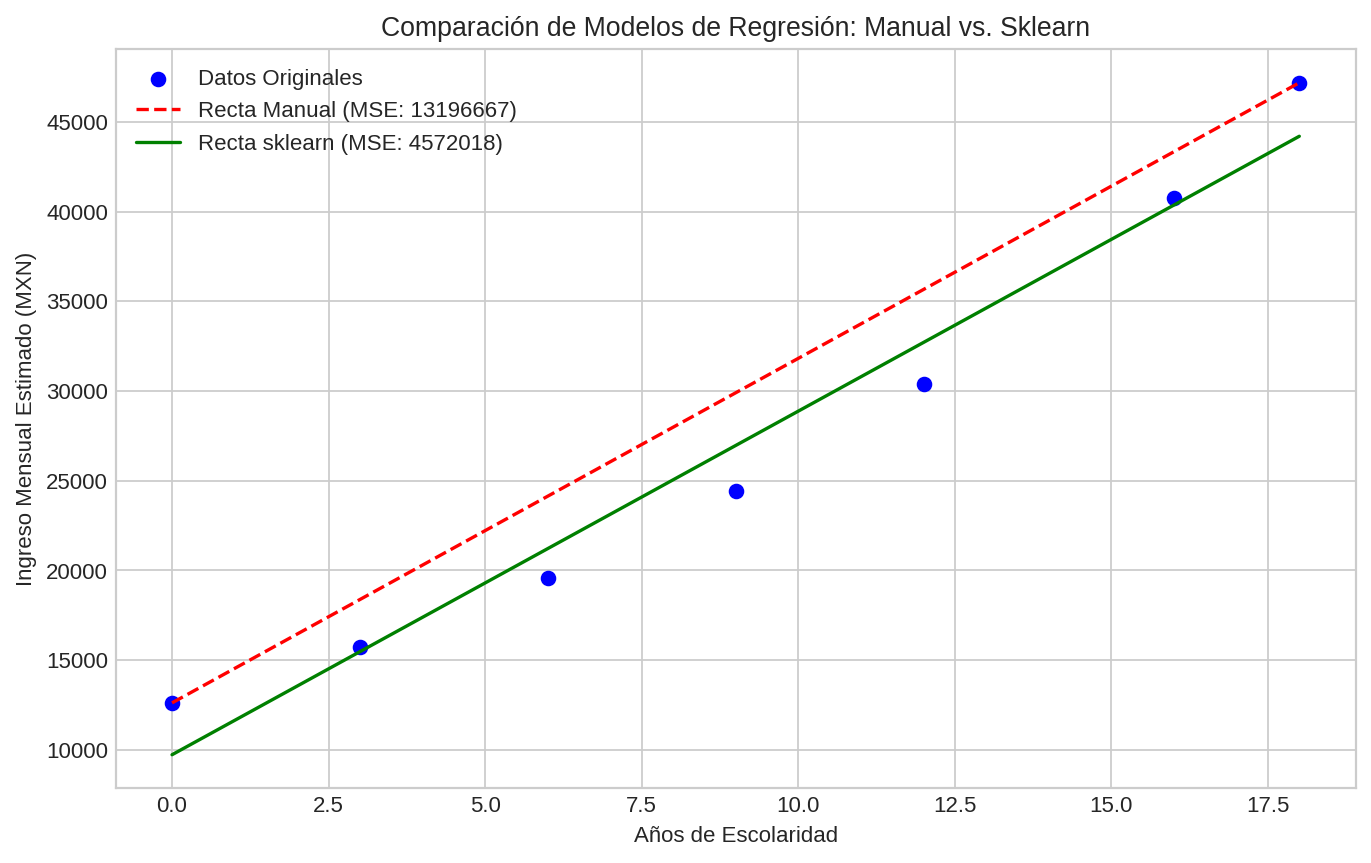

MSE Manual: 13196667.31
MSE sklearn: 4572017.80


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Datos originales
anios_escolaridad = np.array([0, 3, 6, 9, 12, 16, 18])
ingreso_mensual_estimado_mx = np.array([12621, 15723, 19587, 24401, 30398, 40747, 47176])

# --- Modelo 1: Manual (Usando primer y último punto) ---
x1, y1 = anios_escolaridad[0], ingreso_mensual_estimado_mx[0]
x2, y2 = anios_escolaridad[-1], ingreso_mensual_estimado_mx[-1]
m_manual = (y2 - y1) / (x2 - x1)
b_manual = y1 - m_manual * x1
y_pred_manual = m_manual * anios_escolaridad + b_manual
mse_manual = mean_squared_error(ingreso_mensual_estimado_mx, y_pred_manual)

# --- Modelo 2: Scikit-learn ---
X = anios_escolaridad.reshape(-1, 1)
y = ingreso_mensual_estimado_mx
modelo_regresion = LinearRegression()
modelo_regresion.fit(X, y)
m_sklearn = modelo_regresion.coef_[0]
b_sklearn = modelo_regresion.intercept_
y_pred_sklearn = modelo_regresion.predict(X)
mse_sklearn = mean_squared_error(y, y_pred_sklearn)

# --- Graficación ---
plt.figure(figsize=(10, 6))
plt.scatter(anios_escolaridad, ingreso_mensual_estimado_mx, color='blue', label='Datos Originales')
plt.plot(anios_escolaridad, y_pred_manual, color='red', linestyle='--', label=f'Recta Manual (MSE: {mse_manual:.0f})')
plt.plot(anios_escolaridad, y_pred_sklearn, color='green', label=f'Recta sklearn (MSE: {mse_sklearn:.0f})')

plt.title('Comparación de Modelos de Regresión: Manual vs. Sklearn')
plt.xlabel('Años de Escolaridad')
plt.ylabel('Ingreso Mensual Estimado (MXN)')
plt.legend()
plt.grid(True)
plt.show()

print(f"MSE Manual: {mse_manual:.2f}")
print(f"MSE sklearn: {mse_sklearn:.2f}")

1. Gráfica de la regresión de sklearn y datos originalesEn la gráfica se muestran los datos originales (puntos azules), la recta calculada manualmente mediante el primer y último punto (línea roja discontinua) y la recta óptima obtenida con sklearn (línea verde).    
2. Cálculo del MSE y ComparaciónA continuación, se presentan los resultados de los errores calculados:MSE del modelo manual: $13,196,667.31$MSE del modelo sklearn: $4,572,017.80$     
3. Conclusión¿Cuál recta tiene menos error?La recta del modelo de scikit-learn (sklearn) tiene un error significativamente menor en comparación con la recta trazada manualmente. Esto se debe a que sklearn utiliza el método de Mínimos Cuadrados Ordinarios, el cual busca minimizar la suma de los cuadrados de las diferencias entre los valores observados y los predichos para todo el conjunto de datos, no solo para los extremos.

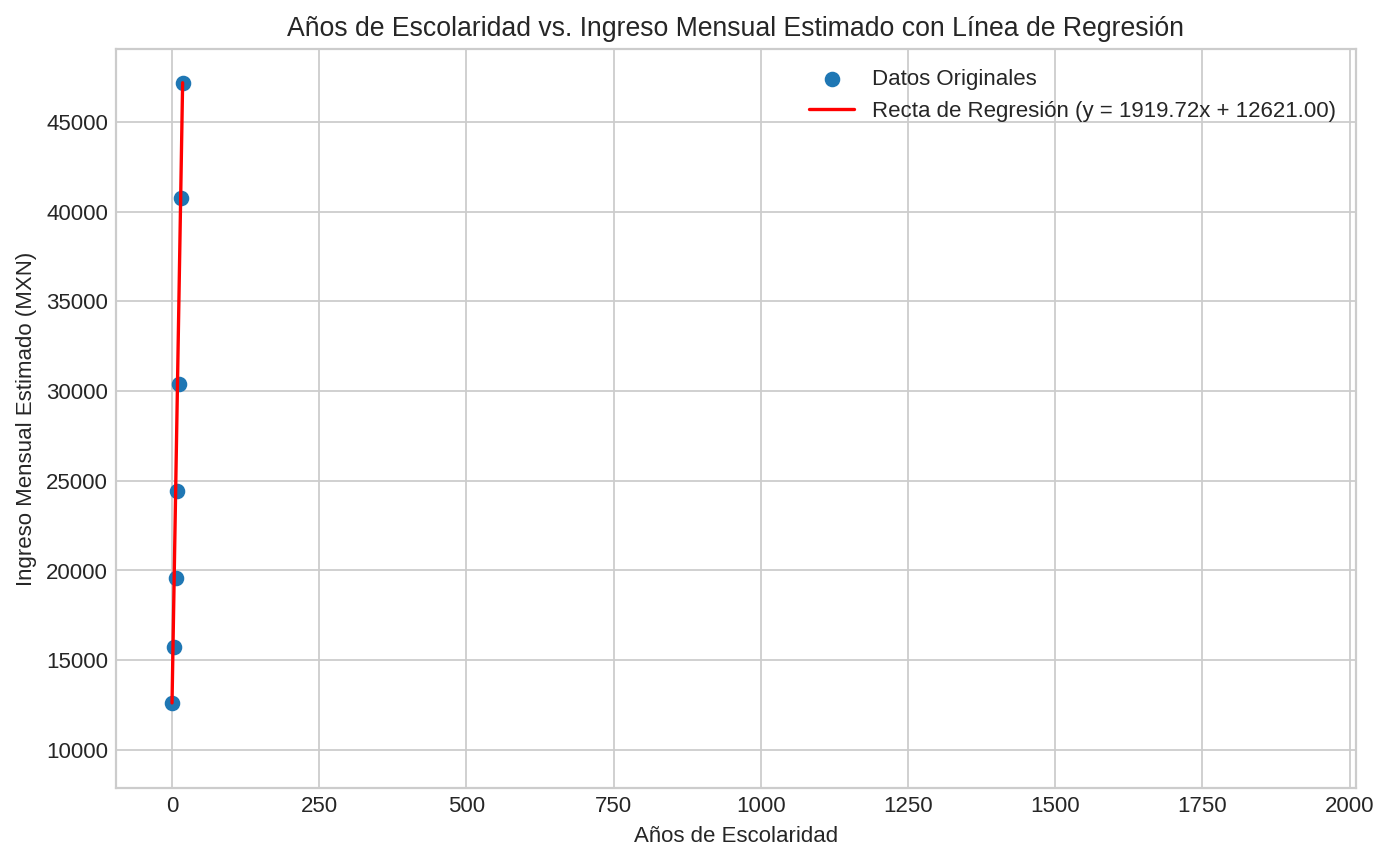

In [ ]:
import matplotlib.pyplot as plt

# Calcular los valores y de la recta utilizando m y b
linea_ingreso_estimado_new_plot = m * anios_escolaridad + b

plt.figure(figsize=(10, 6))
plt.scatter(anios_escolaridad, ingreso_mensual_estimado_mx, label='Datos Originales')
plt.plot(anios_escolaridad, linea_ingreso_estimado_new_plot, color='red',
         label=f'Recta de Regresión (y = {m:.2f}x + {b:.2f})')
plt.plot(m_sklearn,b_sklearn)
plt.title('Años de Escolaridad vs. Ingreso Mensual Estimado con Línea de Regresión')
plt.xlabel('Años de Escolaridad')
plt.ylabel('Ingreso Mensual Estimado (MXN)')
plt.grid(True)
plt.legend()
plt.show()

Pandas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
s=pd.Series([1,3,5,np.nan,6,8])

In [ ]:
s

,0
0,1.0
1,3.0
2,5.0
3,NaN
4,6.0
5,8.0


In [ ]:
dates = pd.date_range("20130101", periods=6)

In [ ]:
dates

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06'],
              dtype='datetime64[ns]', freq='D')

In [ ]:
df = pd.DataFrame(np.random.randn(6, 4), index=dates, columns=list("ABCD"))

In [ ]:
df

,A,B,C,D
2013-01-01,1.069612,-0.653084,-1.525985,0.072199
2013-01-02,0.151777,-1.567646,0.788859,-0.002703
2013-01-03,-1.412350,0.016045,0.561918,-2.630248
2013-01-04,-0.424070,2.157531,1.392111,0.618938
2013-01-05,1.370949,-1.651606,1.758806,-0.240658
2013-01-06,1.011041,0.062829,0.367019,0.484154


In [ ]:
df2 = pd.DataFrame(
    {
        "A": 1.0,
        "B": pd.Timestamp("20130102"),
        "C": pd.Series(1, index=list(range(4)), dtype="float32"),
        "D": np.array([3] * 4, dtype="int32"),
        "E": pd.Categorical(["test", "train", "test", "train"]),
        "F": "foo",
    }
)

In [ ]:
df2

,A,B,C,D,E,F
0,1.0,2013-01-02,1.0,3,test,foo
1,1.0,2013-01-02,1.0,3,train,foo
2,1.0,2013-01-02,1.0,3,test,foo
3,1.0,2013-01-02,1.0,3,train,foo


In [ ]:
df2.dtypes

,0
A,float64
B,datetime64[s]
C,float32
D,int32
E,category
F,object


In [ ]:
df.head()

,A,B,C,D
2013-01-01,1.069612,-0.653084,-1.525985,0.072199
2013-01-02,0.151777,-1.567646,0.788859,-0.002703
2013-01-03,-1.412350,0.016045,0.561918,-2.630248
2013-01-04,-0.424070,2.157531,1.392111,0.618938
2013-01-05,1.370949,-1.651606,1.758806,-0.240658


In [ ]:
df.tail(3)

,A,B,C,D
2013-01-04,-0.424070,2.157531,1.392111,0.618938
2013-01-05,1.370949,-1.651606,1.758806,-0.240658
2013-01-06,1.011041,0.062829,0.367019,0.484154


In [ ]:
df.index

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06'],
              dtype='datetime64[ns]', freq='D')

In [ ]:
df.columns

Index(['A', 'B', 'C', 'D'], dtype='object')

In [ ]:
df.to_numpy()

array([[ 1.06961159, -0.65308393, -1.52598525,  0.07219889],
       [ 0.15177672, -1.56764625,  0.78885865, -0.00270312],
       [-1.41234983,  0.0160447 ,  0.5619185 , -2.63024759],
       [-0.42407026,  2.15753115,  1.39211124,  0.61893822],
       [ 1.3709485 , -1.65160636,  1.75880568, -0.24065841],
       [ 1.01104108,  0.06282899,  0.36701907,  0.48415425]])

In [ ]:
df.describe()

,A,B,C,D
count,6.000000,6.000000,6.000000,6.000000
mean,0.294493,-0.272655,0.557121,-0.283053
std,1.069862,1.401780,1.146338,1.193157
min,-1.412350,-1.651606,-1.525985,-2.630248
25%,-0.280109,-1.339006,0.415744,-0.181170
50%,0.581409,-0.318520,0.675389,0.034748
75%,1.054969,0.051133,1.241298,0.381165
max,1.370949,2.157531,1.758806,0.618938


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Tamaño y estilo de gráficos
plt.rcParams["figure.dpi"] = 160
plt.style.use('seaborn-v0_8-whitegrid')

# Cargar datos
df = pd.read_csv('/content/drive/MyDrive/raw.csv')
df.columns = [c.strip() for c in df.columns]



In [ ]:
df

,Marca temporal,Número de matrícula,¿Cuántos años cumplidos tienes?,¿Has realizado programas utilizando Python?,¿Has utilizado Google Colab?,¿Tienes cuenta de GitHub?
0,19/01/2026 18:32:18,178920,22,Si,No,Si
1,19/01/2026 18:32:23,182712,21,Si,No,Si
2,19/01/2026 18:32:25,180370,26,Si,Si,Si
3,19/01/2026 18:32:27,182570,21,Si,Si,Si
4,19/01/2026 18:32:28,177622,24,Si,No,Si
5,19/01/2026 18:32:29,175166,22,Si,Si,Si
6,19/01/2026 18:32:30,177573,22,Si,Si,Si
7,19/01/2026 18:32:35,178430,21,Si,Si,Si
8,19/01/2026 18:32:38,179169,23,Si,No,Si
9,19/01/2026 18:32:41,177263,22,Si,Si,Si


In [ ]:
df.head()

,Marca temporal,Número de matrícula,¿Cuántos años cumplidos tienes?,¿Has realizado programas utilizando Python?,¿Has utilizado Google Colab?,¿Tienes cuenta de GitHub?
0,19/01/2026 18:32:18,178920,22,Si,No,Si
1,19/01/2026 18:32:23,182712,21,Si,No,Si
2,19/01/2026 18:32:25,180370,26,Si,Si,Si
3,19/01/2026 18:32:27,182570,21,Si,Si,Si
4,19/01/2026 18:32:28,177622,24,Si,No,Si


In [ ]:
df.tail(3)

,Marca temporal,Número de matrícula,¿Cuántos años cumplidos tienes?,¿Has realizado programas utilizando Python?,¿Has utilizado Google Colab?,¿Tienes cuenta de GitHub?
57,19/01/2026 20:22:32,178378,22,Si,No,Si
58,19/01/2026 20:22:50,177451,22,Si,No,Si
59,19/01/2026 20:23:15,179804,21,Si,No,Si


In [ ]:
df.index

RangeIndex(start=0, stop=60, step=1)

In [ ]:
df.rename(columns={'¿Cuántos años cumplidos tienes?':'edad'})

,Marca temporal,Número de matrícula,edad,¿Has realizado programas utilizando Python?,¿Has utilizado Google Colab?,¿Tienes cuenta de GitHub?
0,19/01/2026 18:32:18,178920,22,Si,No,Si
1,19/01/2026 18:32:23,182712,21,Si,No,Si
2,19/01/2026 18:32:25,180370,26,Si,Si,Si
3,19/01/2026 18:32:27,182570,21,Si,Si,Si
4,19/01/2026 18:32:28,177622,24,Si,No,Si
5,19/01/2026 18:32:29,175166,22,Si,Si,Si
6,19/01/2026 18:32:30,177573,22,Si,Si,Si
7,19/01/2026 18:32:35,178430,21,Si,Si,Si
8,19/01/2026 18:32:38,179169,23,Si,No,Si
9,19/01/2026 18:32:41,177263,22,Si,Si,Si


In [ ]:
df.describe()

,Número de matrícula,¿Cuántos años cumplidos tienes?
count,60.000000,60.000000
mean,178446.866667,22.300000
std,2694.322817,1.356716
min,171513.000000,20.000000
25%,177179.750000,21.000000
50%,178348.000000,22.000000
75%,179934.000000,23.000000
max,183060.000000,26.000000


Escalas de Medición

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 200

df = pd.DataFrame({
"id_cliente": range(1, n+1),
"genero": np.random.choice(["F", "M", "No binario", "Prefiero no decir"], size=n, p=[0.45, 0.45, 0.05, 0.05]),
"segmento": np.random.choice(["Estándar", "Oro", "Platino"], size=n, p=[0.6, 0.3, 0.1]),
"satisfaccion": np.random.choice([1,2,3,4,5], size=n, p=[0.1,0.2,0.35,0.25,0.1]),
"ciudad": np.random.choice(["SLP", "CDMX", "GDL", "MTY", "QRO"], size=n, p=[0.35,0.25,0.15,0.15,0.10]),
"edad": np.random.normal(35, 10, size=n).round(0).clip(18, 70).astype(int),
"ingreso_mensual": np.random.lognormal(mean=9.5, sigma=0.5, size=n).round(2), # pesos MXN aprox.
"temperatura_sala": np.random.normal(23, 2, size=n).round(1),
"visitas_ultimo_anio": np.random.poisson(lam=3, size=n),
"fecha_ultima_visita": pd.to_datetime("2025-12-31") - pd.to_timedelta(np.random.randint(0, 365, size=n), unit="D")
})

df.head(6)


,id_cliente,genero,segmento,satisfaccion,ciudad,edad,ingreso_mensual,temperatura_sala,visitas_ultimo_anio,fecha_ultima_visita
0,1,F,Oro,2,SLP,27,10315.01,24.0,4,2025-04-08
1,2,Prefiero no decir,Estándar,5,SLP,40,27029.22,21.9,1,2025-05-11
2,3,M,Estándar,3,SLP,54,42169.36,23.0,3,2025-02-14
3,4,M,Oro,4,SLP,48,11143.16,27.3,4,2025-02-24
4,5,F,Oro,3,SLP,51,10691.98,26.5,6,2025-03-06
5,6,F,Estándar,4,CDMX,30,27630.96,23.9,2,2025-01-09


In [ ]:
df.dtypes

,0
id_cliente,int64
genero,object
segmento,object
satisfaccion,int64
ciudad,object
edad,int64
ingreso_mensual,float64
temperatura_sala,float64
visitas_ultimo_anio,int64
fecha_ultima_visita,datetime64[ns]


**2) Tipado correcto por escala  **

Nominal: genero, ciudad, id_cliente (como identificador, no lo analices).   

Ordinal: segmento, satisfaccion (con orden definido).   

Intervalo: temperatura_sala (°C tiene 0 arbitrario; diferencias sí tienen sentido).   

Razón: edad, ingreso_mensual, visitas_ultimo_anio (tienen cero absoluto y proporciones).   

In [ ]:
# Nominal → category (sin orden)
df["genero"] = df["genero"].astype("category")
df["ciudad"] = df["ciudad"].astype("category")

# Ordinal → category con orden
segmento_cat = pd.CategoricalDtype(categories=["Estándar", "Oro", "Platino"], ordered=True)
df["segmento"] = df["segmento"].astype(segmento_cat)

satisfaccion_cat = pd.CategoricalDtype(categories=[1,2,3,4,5], ordered=True)
df["satisfaccion"] = df["satisfaccion"].astype(satisfaccion_cat)

# Intervalo / Razón → numérico (ya están), pero verifica:
df["temperatura_sala"] = pd.to_numeric(df["temperatura_sala"])
df["edad"] = pd.to_numeric(df["edad"])
df["ingreso_mensual"] = pd.to_numeric(df["ingreso_mensual"])
df["visitas_ultimo_anio"] = pd.to_numeric(df["visitas_ultimo_anio"])

# Derivada útil: días desde última visita (razón)
df["dias_desde_ultima_visita"] = (pd.to_datetime("2025-12-31") - df["fecha_ultima_visita"]).dt.days

In [ ]:
df.dtypes

,0
id_cliente,int64
genero,category
segmento,category
satisfaccion,category
ciudad,category
edad,int64
ingreso_mensual,float64
temperatura_sala,float64
visitas_ultimo_anio,int64
fecha_ultima_visita,datetime64[ns]


**3) Análisis descriptivo apropiado según escala**

Nominal (frecuencias y proporciones):

In [ ]:
freq_genero = df["genero"].value_counts().to_frame("frecuencia")
prop_genero = df["genero"].value_counts(normalize=True).round(3).to_frame("proporcion")
tabla_genero = freq_genero.join(prop_genero)
tabla_genero

,frecuencia,proporcion
genero,,
F,96,0.480
M,85,0.425
No binario,11,0.055
Prefiero no decir,8,0.040


**Ordinal (distribución y tendencia central robusta — mediana):**

In [ ]:
dist_satisfaccion = df["satisfaccion"].value_counts().sort_index().to_frame("frecuencia")
mediana_satisfaccion = df["satisfaccion"].astype(int).median() # convertir para calcular
dist_segmento = df["segmento"].value_counts().sort_index().to_frame("frecuencia")
mediana_satisfaccion, dist_satisfaccion, dist_segmento

(3.0,
               frecuencia
 satisfaccion            
 1                     23
 2                     33
 3                     71
 4                     43
 5                     30,
           frecuencia
 segmento            
 Estándar         113
 Oro               68
 Platino           19)

**Intervalo (media, desviación, pero cuidado con cero):**

In [ ]:
temp_stats = df["temperatura_sala"].agg(["mean", "std", "min", "max"]).round(2)
temp_stats

,temperatura_sala
mean,23.18
std,2.07
min,17.20
max,27.90


**Razón (media, mediana, IQR, coeficiente de variación):**

In [ ]:
def resumen_razon(s):
    return pd.Series({
    "n": s.count(),
    "media": s.mean(),
    "mediana": s.median(),
    "sd": s.std(),
    "min": s.min(),
    "q1": s.quantile(0.25),
    "q3": s.quantile(0.75),
    "max": s.max(),
    "cv": s.std()/s.mean() if s.mean()!=0 else np.nan
    }).round(2)

razon_stats = pd.concat({
    "edad": resumen_razon(df["edad"]),
    "ingreso_mensual": resumen_razon(df["ingreso_mensual"]),
    "visitas_ultimo_anio": resumen_razon(df["visitas_ultimo_anio"]),
    "dias_desde_ultima_visita": resumen_razon(df["dias_desde_ultima_visita"])
    }, axis=1)
razon_stats

,edad,ingreso_mensual,visitas_ultimo_anio,dias_desde_ultima_visita
n,200.00,200.00,200.00,200.00
media,35.05,16258.11,2.96,188.99
mediana,35.00,14682.74,3.00,176.50
sd,9.61,8223.99,1.68,106.72
min,18.00,3976.11,0.00,4.00
q1,29.00,10201.25,2.00,100.75
q3,41.25,19436.38,4.00,283.25
max,61.00,47262.21,8.00,364.00
cv,0.27,0.51,0.57,0.56


**4) Visualizaciones adecuadas por escala (opcional)**

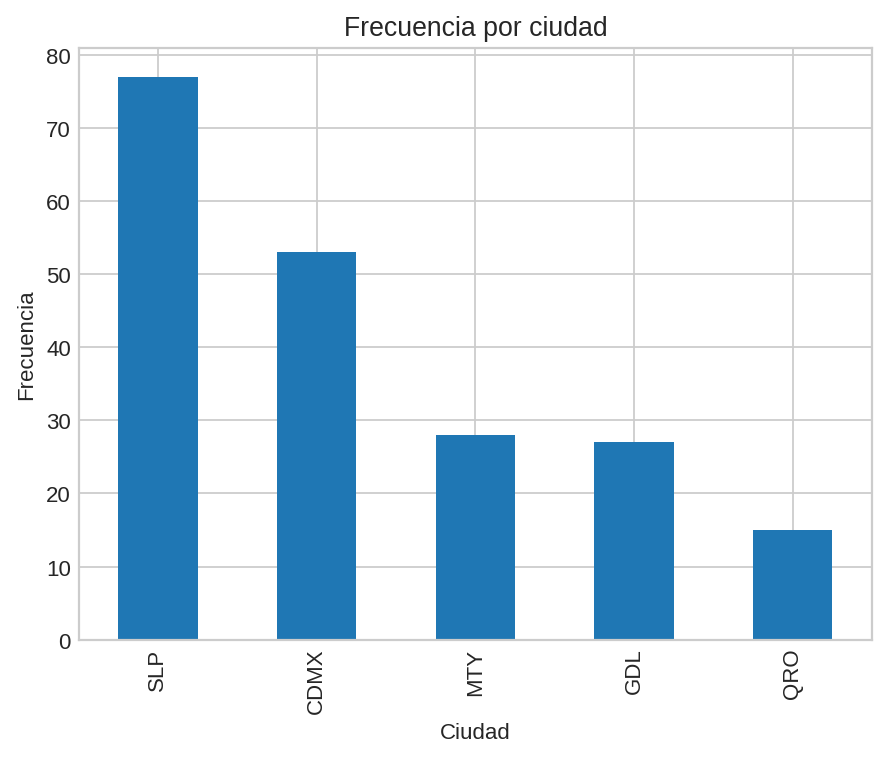

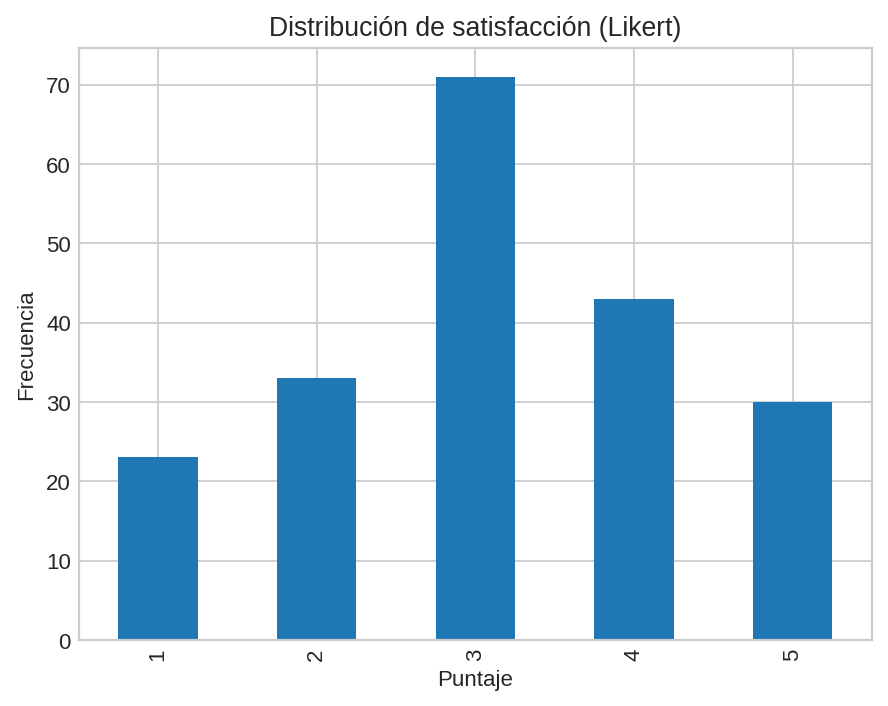

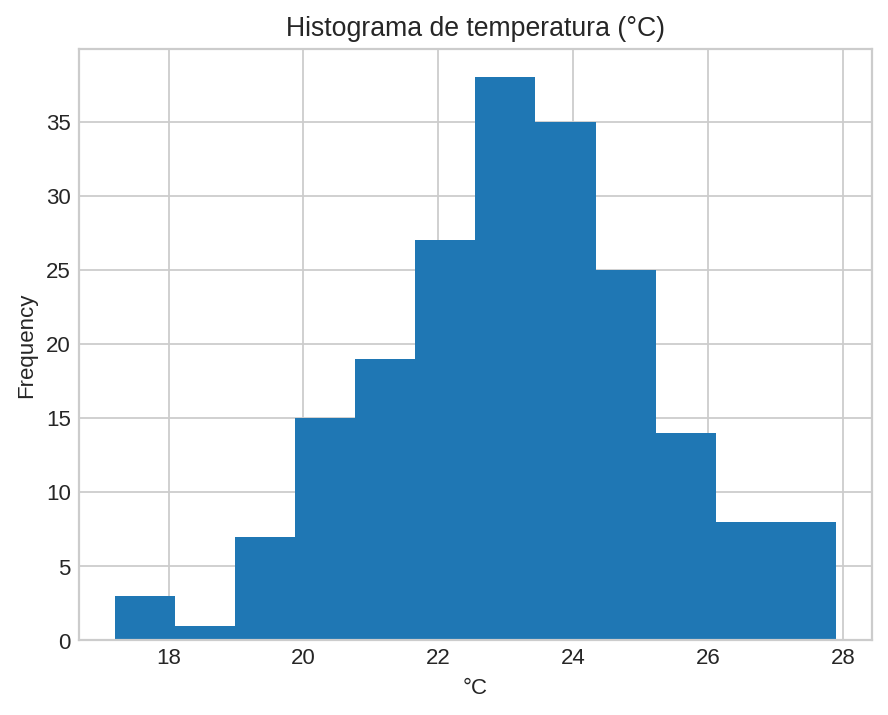

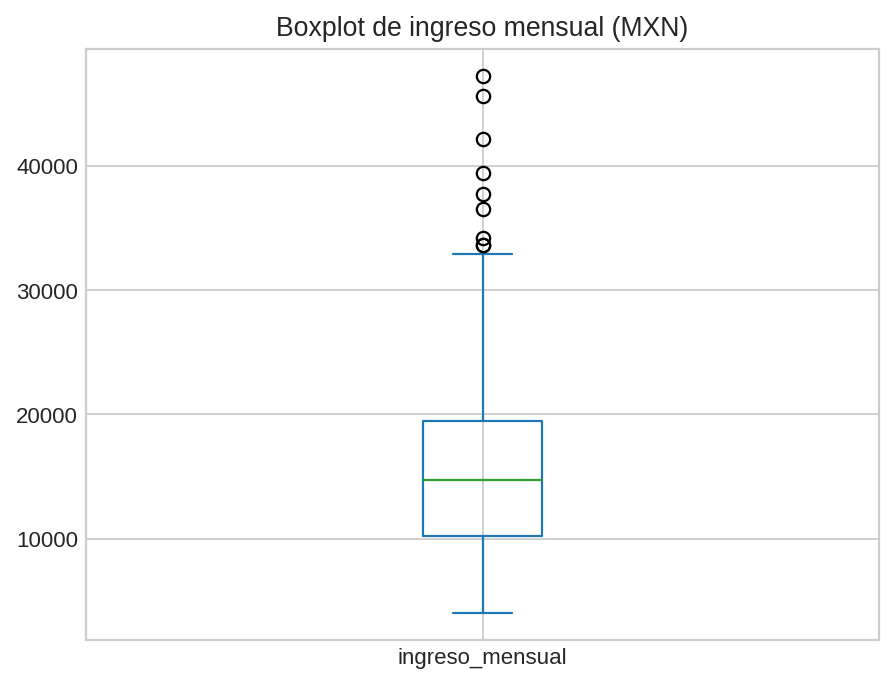

In [ ]:
import matplotlib.pyplot as plt

# Nominal: barras
df["ciudad"].value_counts().plot(kind="bar", title="Frecuencia por ciudad")
plt.xlabel("Ciudad"); plt.ylabel("Frecuencia"); plt.show()

# Ordinal: barra ordenada por categorías
df["satisfaccion"].value_counts().sort_index().plot(kind="bar", title="Distribución de satisfacción (Likert)")
plt.xlabel("Puntaje"); plt.ylabel("Frecuencia"); plt.show()

# Intervalo: histograma de temperatura
df["temperatura_sala"].plot(kind="hist", bins=12, title="Histograma de temperatura (°C)")
plt.xlabel("°C"); plt.show()

# Razón: boxplot de ingreso (suele ser asimétrico)
df[["ingreso_mensual"]].plot(kind="box", title="Boxplot de ingreso mensual (MXN)")
plt.show()


**5) Cruces y análisis según escala**

Nominal × Nominal: tabla de contingencia + chi-cuadrado (si procede).

Ordinal × Razón: comparar medias/medianas por categoría ordenada.

In [ ]:
# Ordinal × Ordinal: asociación ordinal (p. ej., tendencia entre segmento y satisfaccion).
# Nominal × Nominal
ct_ciudad_genero = pd.crosstab(df["ciudad"], df["genero"], normalize="index").round(3)
ct_ciudad_genero

# Ordinal × Razón (grupos por segmento)
ingreso_por_segmento = df.groupby("segmento")["ingreso_mensual"].agg(["count","median","mean","std"]).round(2)
ingreso_por_segmento

# Ordinal × Ordinal: correlación de Spearman entre satisfacción y segmento
spearman = df.assign(
satisfaccion_num = df["satisfaccion"].astype(int),
segmento_num = df["segmento"].cat.codes + 1 # Estándar=1, Oro=2, Platino=3
)[["satisfaccion_num","segmento_num"]].corr(method="spearman").iloc[0,1]
spearman

/tmp/ipython-input-2583011555.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ingreso_por_segmento = df.groupby("segmento")["ingreso_mensual"].agg(["count","median","mean","std"]).round(2)


np.float64(-0.040233892283196265)

6) Buenas prácticas (verificaciones)   
* No uses media para nominal/ordinal (excepto ordinal con precaución si tratas los valores como numéricos y lo justificas).
* Para intervalo, evita hacer afirmaciones del tipo “el doble de temperatura” en °C.
Para razón, sí puedes hablar de proporciones y “el doble que…”.
* Si hay outliers (p. ej., en ingreso_mensual), usa mediana o IQR además de la media.


Reto adicional  
* Crea una variable binaria: alto_ingreso = ingreso_mensual >= Q3. (Nominal dicotómica)
* Compara la distribución de satisfacción entre alto_ingreso=True/False con un gráfico de barras apiladas.
* Calcula días_desde_ultima_visita por segmento y evalúa si hay tendencia.


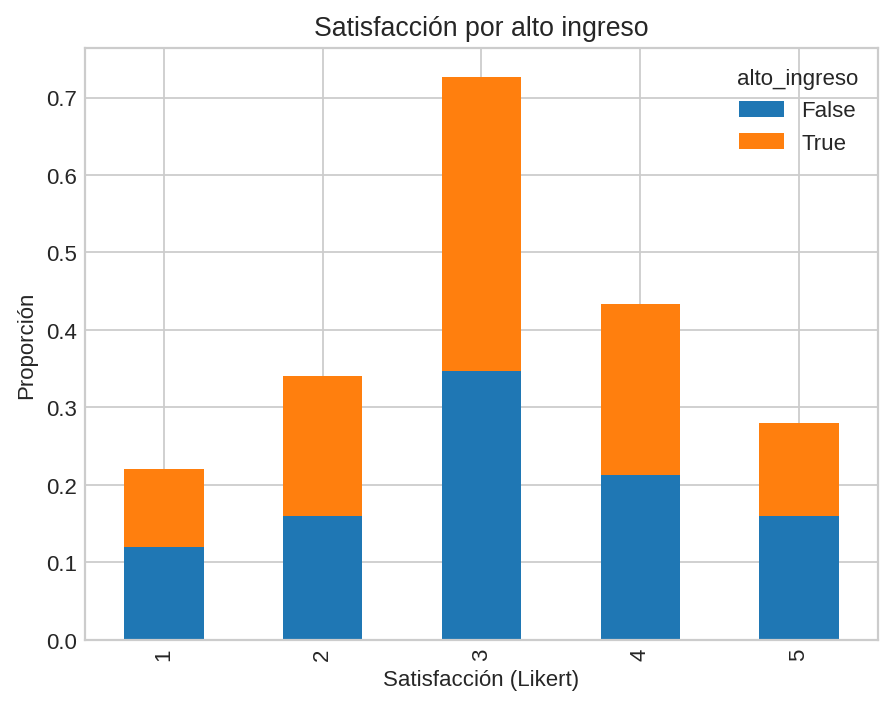

/tmp/ipython-input-3547524051.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dias_seg = df.groupby("segmento")["dias_desde_ultima_visita"].median()


,dias_desde_ultima_visita
segmento,
Estándar,171.0
Oro,189.0
Platino,183.0


In [ ]:
Q3 = df["ingreso_mensual"].quantile(0.75)
df["alto_ingreso"] = (df["ingreso_mensual"] >= Q3).astype("category")

# Barras apiladas: satisfacción x alto_ingreso
tabla = pd.crosstab(df["satisfaccion"], df["alto_ingreso"], normalize="columns").round(3)
tabla.plot(kind="bar", stacked=True, title="Satisfacción por alto ingreso")
plt.xlabel("Satisfacción (Likert)"); plt.ylabel("Proporción"); plt.show()

# Tendencia en días desde última visita por segmento
dias_seg = df.groupby("segmento")["dias_desde_ultima_visita"].median() #groupBy TOMA UN segmneto
dias_seg

In [ ]:
Q3

np.float64(19436.375)

**Preguntas guía para el informe**  
¿Qué variables son nominales, ordinales, de intervalo y de razón? Da

* ¿Qué medidas resumen usaste para cada tipo y por qué?
* ¿Qué hallazgos obtuviste al cruzar segmento con ingreso_mensual y con satisfaccion?
* ¿Hay asimetría notable en ingreso_mensual? ¿Cómo la trataste?
* ¿Qué recomendarías al negocio con base en los resultados?




**¿Qué es el IQR?**  
NOTAS
* (Diferencia entre cuartil 1 y 3 (q1 y q3)), calculamos el limite inferior  (IQR multiplicado por .25)
* Menor de 13 es aberrabte y arriba de 58  

El IQR significa Interquartile Range o Rango Intercuartílico en español.
Es una medida de dispersión que indica qué tan dispersados están los datos en el 50% central de la distribución.

Se calcula así:
* undefinedQ1 (primer cuartil): el valor debajo del cual se encuentra el 25% de los datos.
* Q3 (tercer cuartil): el valor debajo del cual se encuentra el 75% de los datos.  
➡️ Entonces, el IQR abarca desde el punto donde está el 25% de los datos hasta el 75%.

**¿Para qué sirve el IQR?**
1) Detectar outliers
Un valor se considera atípico si cae fuera de: undefined  
2) Medir dispersión robusta
Es más resistente a valores extremos que la desviación estándar.  
3) Entender la variabilidad real
Sirve para saber qué tan dispersos están los datos en la parte donde sí hay concentración (no en los extremos).

**¿Qué mide exactamente Spearman?**  
Evalúa correlación por rangos, no por valores originales.  
Se usa en datos categoricos (Nominales y Ordinales)

Esto lo hace útil cuando:
* Las variables son ordinales (por ejemplo, niveles de satisfacción).
* La relación no es lineal pero sí monotónica (creciente o decreciente).
* Hay outliers, ya que Spearman es más robusto que Pearson.

**¿Cómo se calcula Spearman?**  
1.   Ordenas los datos → les asignas rangos.
2.   Calculas la correlación Pearson sobre los rangos.  

**Su valor está entre:**
* +1 → relación perfectamente creciente
* -1 → relación perfectamente decreciente
* 0 → no hay relación monotónica



**Teoría de la Correlación en Minería de Datos**  
La correlación (Puede ser que una no cause a la otra) es una herramienta estadística fundamental para entender cómo se relacionan dos variables. Se utiliza en minería de datos, machine learning, análisis exploratorio y ciencia de datos para identificar patrones, dependencias, redundancias, multicolinealidad y posibles causas subyacentes.

A continuación se presenta una teoría extensa y estructurada.  

🧩 **1. ¿Qué es la correlación?**
La correlación mide la fuerza y la dirección de la relación entre dos variables numéricas.

* Dirección: positiva o negativa
* Fuerza: débil, moderada o fuerte
* Tipo de relación: lineal o monótona (no necesariamente lineal)
La correlación NO implica causalidad, pero sí puede ser indicio útil para plantear hipótesis, modelar variables o detectar redundancias.

➕➖ **2. Signo y magnitud de la correlación**
Dirección
* Positiva (r > 0): cuando una variable aumenta, la otra también.
* Negativa (r < 0): cuando una variable aumenta, la otra disminuye.
* Cero (r = 0): no hay relación lineal observable.


Magnitud (reglas generales)

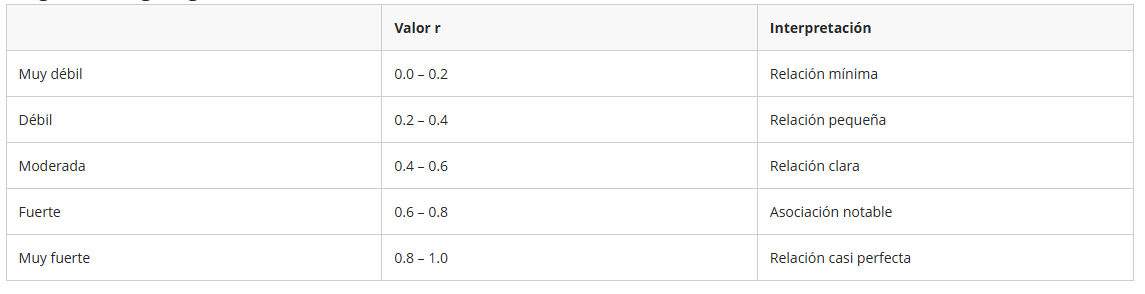

R2 es correlacion lineal mientras mas se acerque a uno y como es positivo es creciente
Si solo tiene R nos indica que es decreciente

3. Tipos de correlación

🔹 **3.1. Correlación de Pearson (r)**  
Mide la relación lineal entre dos variables continuas.

Supuestos:
* Relación aproximadamente lineal
* Variables continuas
* Sin outliers extremos (muy sensibles)
* Aproximadamente normales  

¿Cuándo usarla?
* Cuando la gráfica de dispersión sugiere linealidad.
* Cuando estás construyendo modelos lineales, regresión múltiple o PCA.  

**🔹3.2. Correlación de Spearman (ρ)**  
Mide la relación monótona, usando el rango de los datos.

Características:
* No requiere normalidad
* Mucho más robusta a outliers
* Funciona bien con variables ordinales  

Captura relaciones monótonas no lineales
* ¿Cuándo usarla?
* Cuando la relación no es lineal pero sí monótona (creciente o decreciente).
* Cuando hay outliers o datos muy sesgados.

In [ ]:
numeros=[0,1,2,3,4,5,6,7,8,9,10]
len(numeros)

11

In [ ]:
probabilidad_par = 6/11
probabilidad_par

0.5454545454545454

In [ ]:
probabilidad_impar = 5/11
0.5454545454545454

0.5454545454545454

La probabilidad condicional mide la probabilidad de que ocurra un evento A, sabiendo que ya ocurrió un evento B.

Se denota así:

$$ P ( A | B ) $$

Y su fórmula es:

P ( A  |  B ) = equals fraction numerator P left parenthesis A intersection B right parenthesis over denominator P left parenthesis B right parenthesis end fraction

donde:

P left parenthesis A intersection B right parenthesis: probabilidad de que ocurran A y B a la vez.
P left parenthesis B right parenthesis: probabilidad de que ocurra B.
⚠️ Importante: solo tiene sentido si P left parenthesis B right parenthesis greater than 0.

2. Ejemplo básico
Ejemplo:

En una bolsa hay 5 bolas rojas y 3 verdes. Tomamos una bola al azar.

Sea:

A = “la bola es roja”
B = “la bola es verde o roja” (o sea, cualquier bola…)
Encuentra P left parenthesis A vertical line B right parenthesis.

Como B es todo el espacio, entonces P left parenthesis A vertical line B right parenthesis = P left parenthesis A right parenthesis.

3. Ejemplo más interesante
Ejemplo:

En un salón:

12 estudiantes hablan inglés
8 hablan francés
5 hablan ambos idiomas
Hay 20 estudiantes en total
Encuentra:

a) P(inglés | francés)
Interpretación:

Entre quienes hablan francés, el 62.5% también habla inglés.

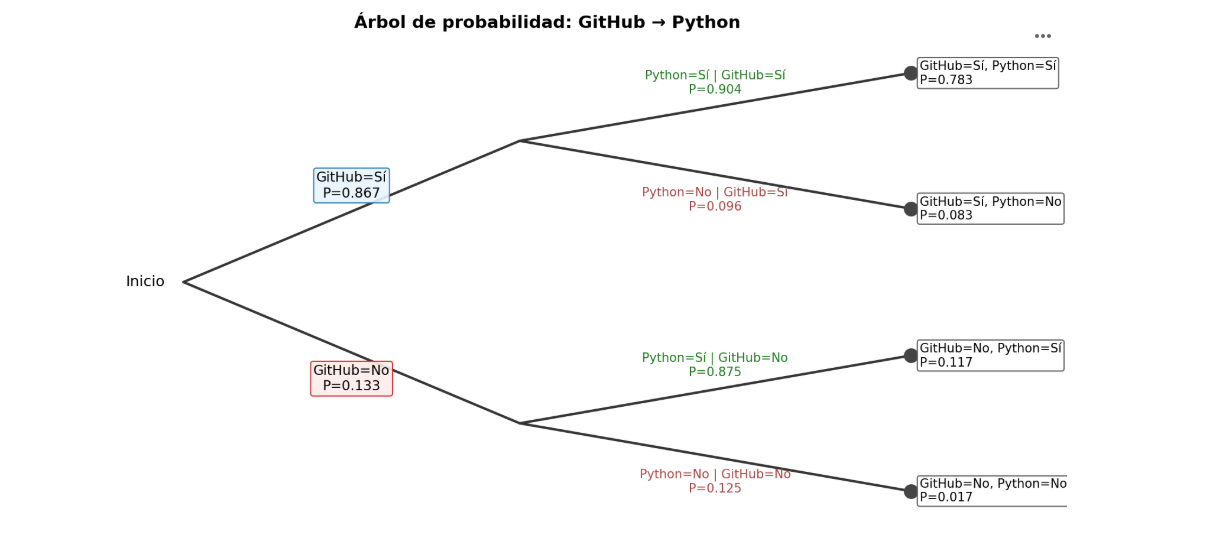

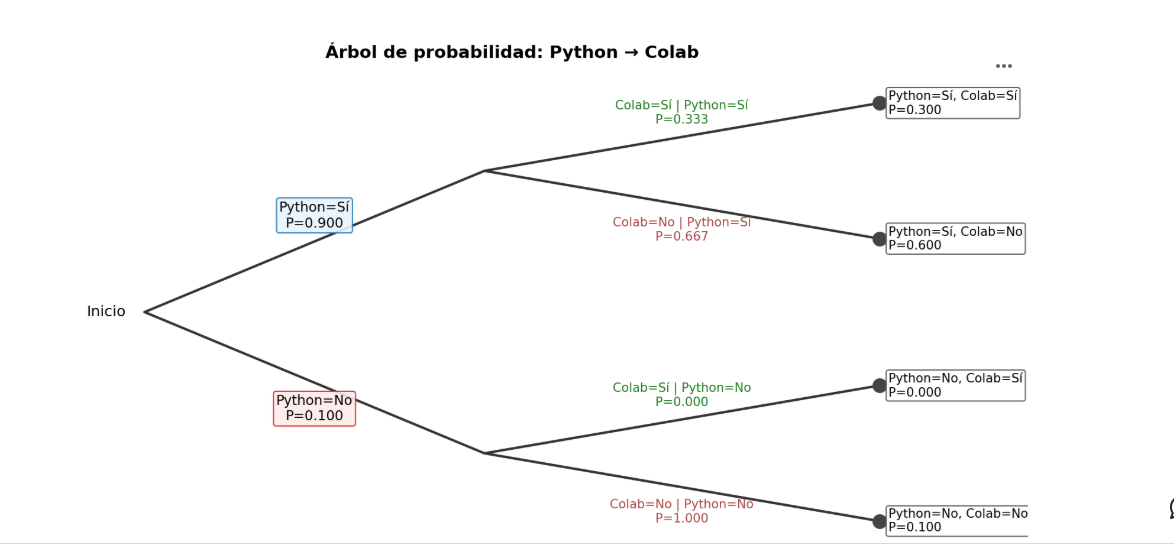

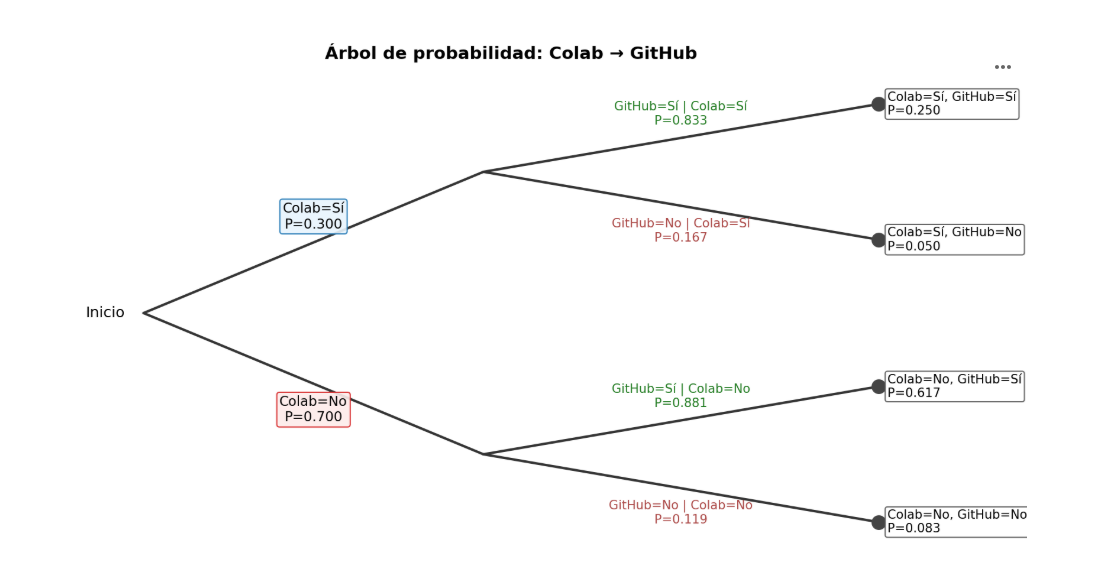

La población de adultos en un pequeño pueblo que han satisfecho los requisitos para graduarse en la escuela. Se deben clasificar de acuerdo con su sexo y a si trabajan o no actualmente.

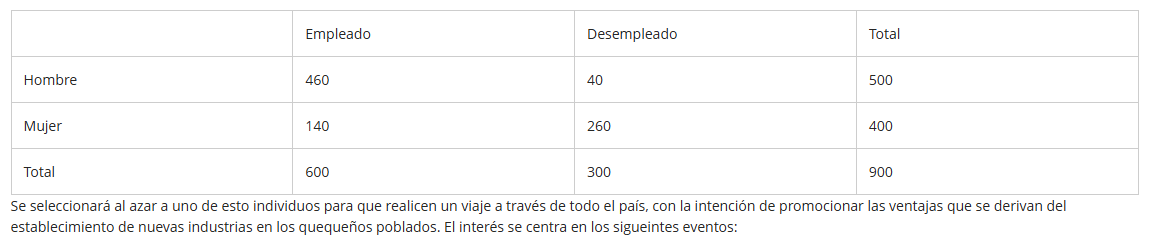

H: se escoge un hombre,

E: el elegido tiene empleo.

Calcule $$P ( H | E )$$


In [ ]:
men_with_employment = 460
total_with_employment = 600

p = men_with_employment / total_with_employment

print(f"The probability P(H|E) is: {p:.4f}")

The probability P(H|E) is: 0.7667


La probabilidad de que un vuelo de programación regular despegue a tiempo es de P(D) = 0.83; la de que llegue a tiempo es de P(A) = 0.82; y la de que despegue y llegue a tiempo P ( D ∩ A )= 0.78. Encuentre la probabilidad de que un avión:

a) Llegue a tiempo dado que despegó a tiempo.

b) despegue a tiempo dado que llegó a tiempo.

In [ ]:
variableA=0.82
variableB=0.78

resultado=variableB/variableA
print(resultado)

0.951219512195122


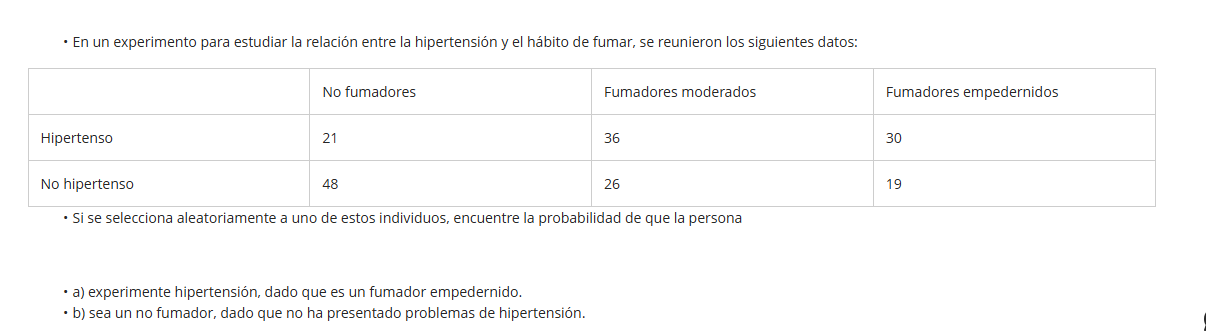

In [ ]:
# a) Probabilidad de que la persona experimente hipertensión, dado que es un fumador empedernido.
# P(H | FE) = N(H and FE) / N(FE)

num_hipertension_fumador_empedernido = 36
total_fumador_empedernido = 75

prob_h_given_fe = num_hipertension_fumador_empedernido / total_fumador_empedernido
print(f"a) P(Hipertensión | Fumador Empedernido) = {prob_h_given_fe:.4f}")

# b) Probabilidad de que la persona sea un no fumador, dado que no ha presentado problemas de hipertensión.
# P(NF | NH) = N(NF and NH) / N(NH)

num_no_fumador_no_hipertension = 65
total_no_hipertension = 140

prob_nf_given_nh = num_no_fumador_no_hipertension / total_no_hipertension
print(f"b) P(No Fumador | No Hipertensión) = {prob_nf_given_nh:.4f}")

a) P(Hipertensión | Fumador Empedernido) = 0.4800
b) P(No Fumador | No Hipertensión) = 0.4643


In [ ]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
iris['species'].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


In [ ]:
X=iris.drop('species',axis=1)
print(X)
y=iris['species']
print(y)

     sepal_length  sepal_width  petal_length  petal_width
0             5.1          3.5           1.4          0.2
1             4.9          3.0           1.4          0.2
2             4.7          3.2           1.3          0.2
3             4.6          3.1           1.5          0.2
4             5.0          3.6           1.4          0.2
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[150 rows x 4 columns]
0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: object


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


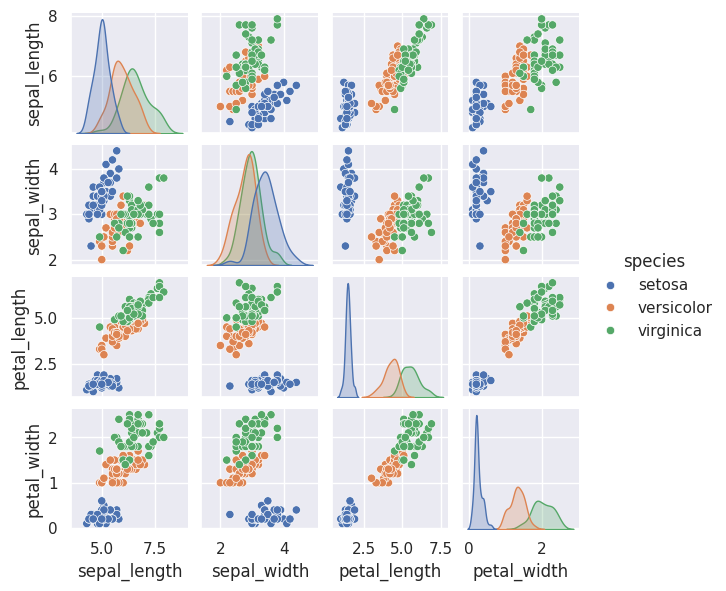

In [ ]:
%matplotlib inline
import seaborn as sns; sns.set()
sns.pairplot(iris, hue='species', size=1.5);

In [ ]:
X_iris = iris.drop('species', axis=1)
X_iris.shape

(150, 4)

In [ ]:
y_iris = iris['species']
y_iris.shape

(150,)

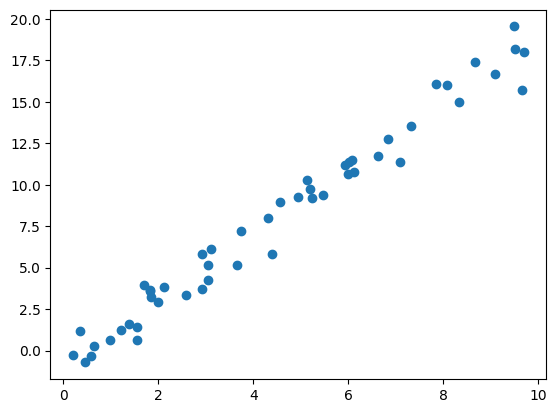

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.RandomState(42)
x = 10 * rng.rand(50)
y = 2 * x - 1 + rng.randn(50)
plt.scatter(x, y);

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression(fit_intercept=True)
model

LinearRegression()

In [ ]:
X = x[:, np.newaxis]
X.shape

(50, 1)

In [ ]:
model.fit(X, y)

LinearRegression()

In [ ]:
model.coef_

array([1.9776566])

In [ ]:
model.intercept_

np.float64(-0.9033107255311146)

In [ ]:
xfit = np.linspace(-1, 11)

In [ ]:
Xfit = xfit[:, np.newaxis]
yfit = model.predict(Xfit)

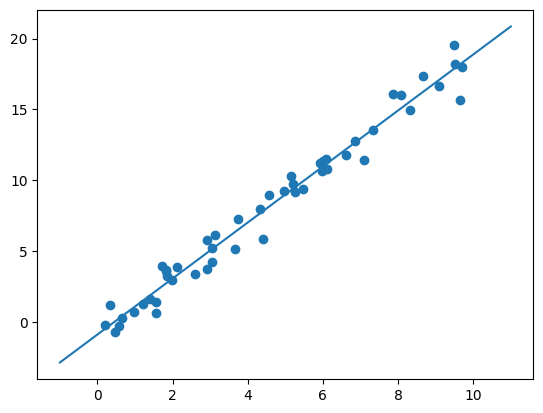

In [ ]:
plt.scatter(x, y)
plt.plot(xfit, yfit);

In [ ]:
xfit = np.linspace(-1, 11)

In [ ]:
Xfit = xfit[:, np.newaxis]
yfit = model.predict(Xfit)

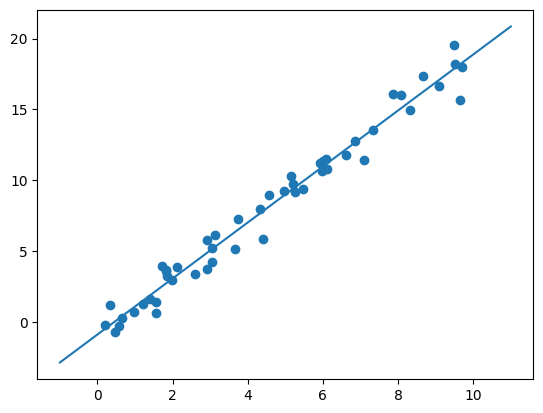

In [ ]:
plt.scatter(x, y)
plt.plot(xfit, yfit);

Supervised learning example: Iris classification

In [ ]:
import seaborn as sns
iris = sns.load_dataset('iris')
X_iris = iris.drop('species', axis=1)
y_iris = iris['species']

from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(X_iris, y_iris,
                                                random_state=1)

In [ ]:
from sklearn.naive_bayes import GaussianNB # 1. choose model class
model = GaussianNB()                       # 2. instantiate model
model.fit(Xtrain, ytrain)                  # 3. fit model to data
y_model = model.predict(Xtest)             # 4. predict on new data

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(ytest, y_model)

0.9736842105263158

Unsupervised learning example: Iris dimensionality

In [ ]:
from sklearn.decomposition import PCA  # 1. Choose the model class
model = PCA(n_components=2)            # 2. Instantiate the model with hyperparameters
model.fit(X_iris)                      # 3. Fit to data. Notice y is not specified!
X_2D = model.transform(X_iris)         # 4. Transform the data to two dimensions

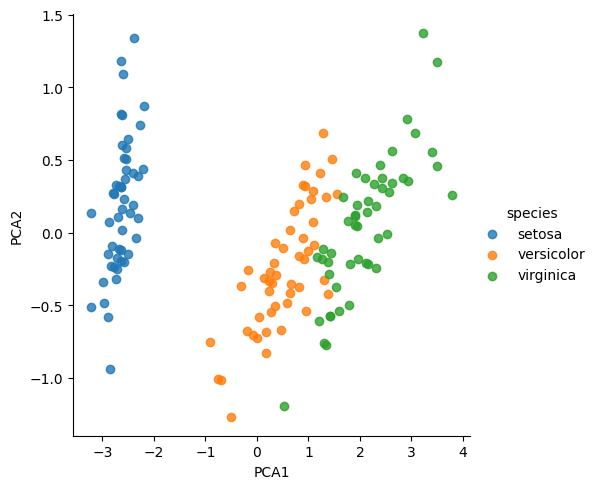

In [ ]:
iris['PCA1'] = X_2D[:, 0]
iris['PCA2'] = X_2D[:, 1]
sns.lmplot(x='PCA1', y='PCA2', hue='species', data=iris, fit_reg=False);

In [ ]:
from sklearn.mixture import GaussianMixture      # 1. Choose the model class
model = GaussianMixture(n_components=3, covariance_type='full')  # 2. Instantiate the model with hyperparameters
model.fit(X_iris)                    # 3. Fit to data. Notice y is not specified!
y_gmm = model.predict(X_iris)        # 4. Determine cluster labels

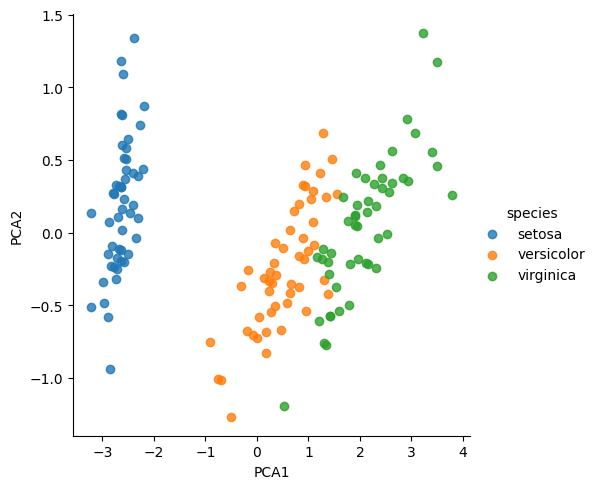

In [ ]:
iris['PCA1'] = X_2D[:, 0]
iris['PCA2'] = X_2D[:, 1]
sns.lmplot(x='PCA1', y='PCA2', hue='species', data=iris, fit_reg=False);

In [ ]:
from sklearn.mixture import GaussianMixture      # 1. Choose the model class
model = GaussianMixture(n_components=3,
            covariance_type='full')  # 2. Instantiate the model with hyperparameters
model.fit(X_iris)                    # 3. Fit to data. Notice y is not specified!
y_gmm = model.predict(X_iris)        # 4. Determine cluster labels

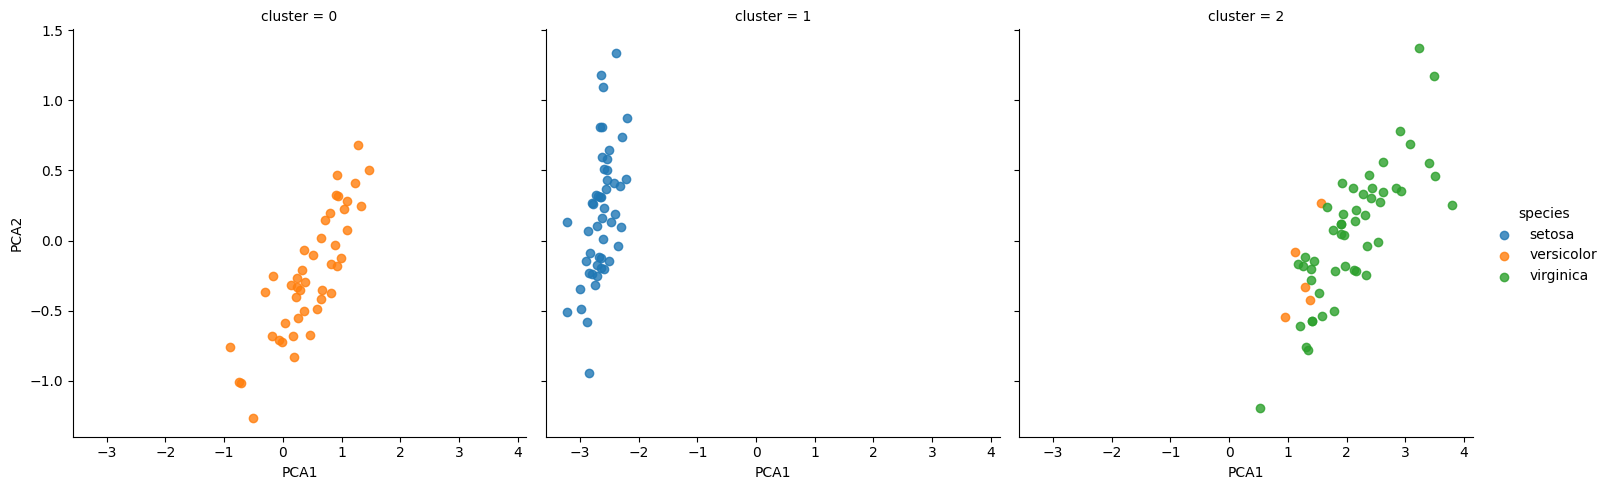

In [ ]:
iris['cluster'] = y_gmm
sns.lmplot(x='PCA1', y='PCA2', data=iris, hue='species',
           col='cluster', fit_reg=False);

In [ ]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.images.shape

(1797, 8, 8)

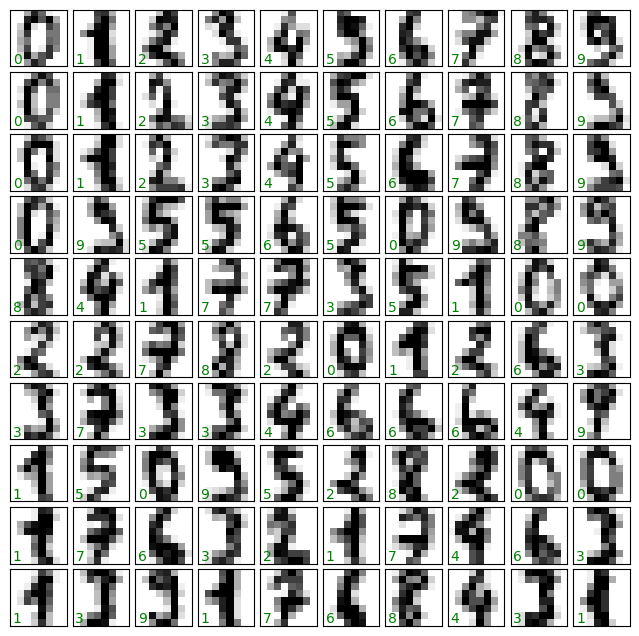

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(10, 10, figsize=(8, 8),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='binary', interpolation='nearest')
    ax.text(0.05, 0.05, str(digits.target[i]),
            transform=ax.transAxes, color='green')

In [ ]:
X = digits.data
X.shape

(1797, 64)

In [ ]:
y = digits.target
y.shape

(1797,)

In [ ]:
from sklearn.manifold import Isomap
iso = Isomap(n_components=2)
iso.fit(digits.data)
data_projected = iso.transform(digits.data)
data_projected.shape

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_isomap.py:360: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


(1797, 2)

/tmp/ipykernel_622/3852404262.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('viridis', 10))


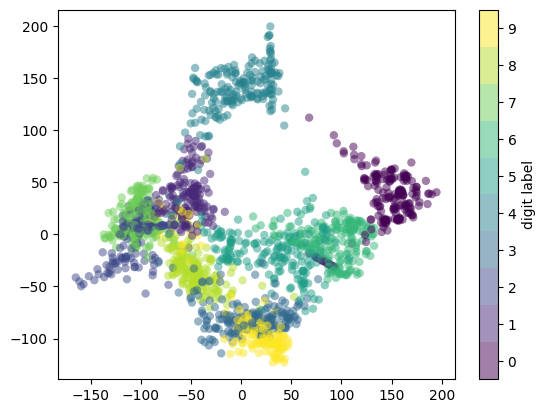

In [ ]:
plt.scatter(data_projected[:, 0], data_projected[:, 1], c=digits.target,
            edgecolor='none', alpha=0.5,
            cmap=plt.cm.get_cmap('viridis', 10))
plt.colorbar(label='digit label', ticks=range(10))
plt.clim(-0.5, 9.5);

##Hyperparameters and Model Validation

In [ ]:
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=1)

In [ ]:
model.fit(X, y)
y_model = model.predict(X)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y, y_model)

1.0

Model validation the right way: Holdout sets

In [ ]:
y2_model = model.fit(X1, y1).predict(X2)
y1_model = model.fit(X2, y2).predict(X1)
accuracy_score(y1, y1_model), accuracy_score(y2, y2_model)

(0.96, 0.9066666666666666)

In [ ]:
from sklearn.model_selection import train_test_split
# split the data with 50% in each set
X1, X2, y1, y2 = train_test_split(X, y, random_state=0,
                                  train_size=0.5)

# fit the model on one set of data
model.fit(X1, y1)

# evaluate the model on the second set of data
y2_model = model.predict(X2)
accuracy_score(y2, y2_model)

0.9066666666666666

In [ ]:
from sklearn.model_selection import cross_val_score
cross_val_score(model, X, y, cv=5)

array([0.96666667, 0.96666667, 0.93333333, 0.93333333, 1.        ])

In [ ]:
from sklearn.model_selection import LeaveOneOut
scores = cross_val_score(model, X, y, cv=LeaveOneOut())
scores

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [ ]:
scores.mean()

np.float64(0.96)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

def PolynomialRegression(degree=2, **kwargs):
    return make_pipeline(PolynomialFeatures(degree),
                         LinearRegression(**kwargs))

In [ ]:
import numpy as np

def make_data(N, err=1.0, rseed=1):
    # randomly sample the data
    rng = np.random.RandomState(rseed)
    X = rng.rand(N, 1) ** 2
    y = 10 - 1. / (X.ravel() + 0.1)
    if err > 0:
        y += err * rng.randn(N)
    return X, y

X, y = make_data(40)

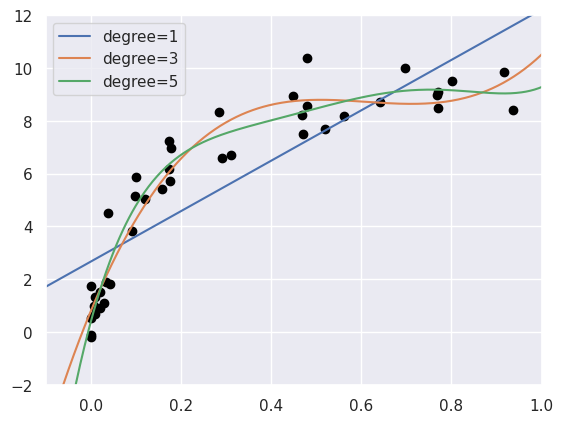

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn; seaborn.set()  # plot formatting

X_test = np.linspace(-0.1, 1.1, 500)[:, None]

plt.scatter(X.ravel(), y, color='black')
axis = plt.axis()
for degree in [1, 3, 5]:
    y_test = PolynomialRegression(degree).fit(X, y).predict(X_test)
    plt.plot(X_test.ravel(), y_test, label='degree={0}'.format(degree))
plt.xlim(-0.1, 1.0)
plt.ylim(-2, 12)
plt.legend(loc='best');

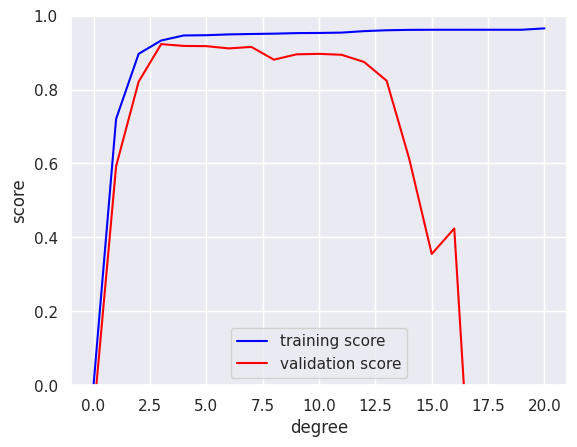

In [ ]:
from sklearn.model_selection import validation_curve
degree = np.arange(0, 21)
train_score, val_score = validation_curve(estimator=PolynomialRegression(),
                                          X=X, y=y,
                                          param_name='polynomialfeatures__degree',
                                          param_range=degree, cv=7)

plt.plot(degree, np.median(train_score, 1), color='blue', label='training score')
plt.plot(degree, np.median(val_score, 1), color='red', label='validation score')
plt.legend(loc='best')
plt.ylim(0, 1)
plt.xlabel('degree')
plt.ylabel('score');

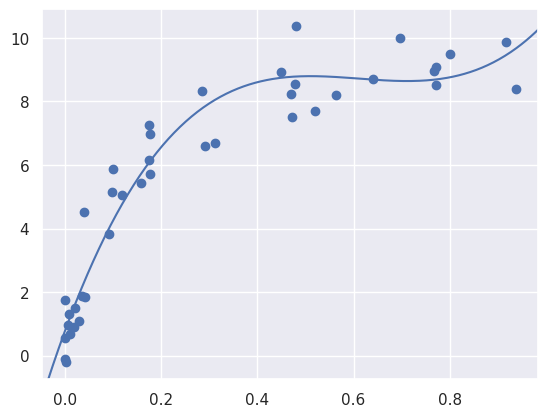

In [ ]:
plt.scatter(X.ravel(), y)
lim = plt.axis()
y_test = PolynomialRegression(3).fit(X, y).predict(X_test)
plt.plot(X_test.ravel(), y_test);
plt.axis(lim);

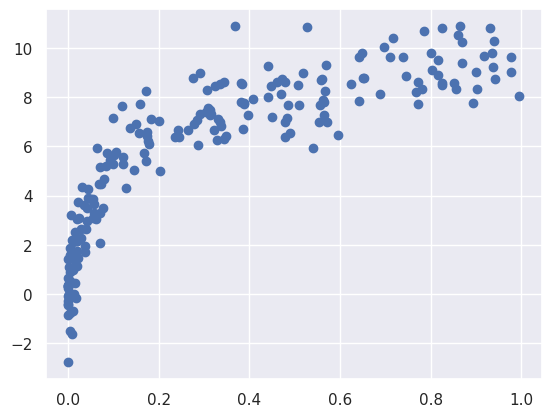

In [ ]:
X2, y2 = make_data(200)
plt.scatter(X2.ravel(), y2);

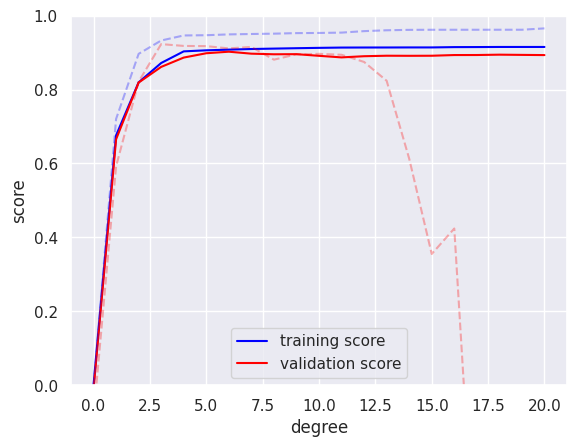

In [ ]:
degree = np.arange(21)
train_score2, val_score2 = validation_curve(estimator=PolynomialRegression(), X=X2, y=y2,
                                            param_name='polynomialfeatures__degree', param_range=degree, cv=7)

plt.plot(degree, np.median(train_score2, 1), color='blue', label='training score')
plt.plot(degree, np.median(val_score2, 1), color='red', label='validation score')
plt.plot(degree, np.median(train_score, 1), color='blue', alpha=0.3, linestyle='dashed')
plt.plot(degree, np.median(val_score, 1), color='red', alpha=0.3, linestyle='dashed')
plt.legend(loc='lower center')
plt.ylim(0, 1)
plt.xlabel('degree')
plt.ylabel('score');